# Breast Cancer Wisconsin：良性・悪性の説明可能な比較

run_id: `v020-exp-32`。公開の細胞核画像由来特徴を探索し、診断支援の検討材料を示す。個人の臨床診断、治療判断、安全な臨床運用の保証には使用しない。

In [22]:
# 初期化とライフサイクル登録
from pathlib import Path
import os, sys, json, hashlib, io, zipfile, contextlib, warnings
from datetime import datetime, timezone
from dataclasses import asdict
repo = Path('/home/nahisaho/GitHub/jupytermind')
if str(repo / 'src') not in sys.path:
    sys.path.insert(0, str(repo / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(repo / 'benchmark/projects')
import numpy as np
import pandas as pd
import nbformat
from IPython.display import display, Markdown
from ai_data_scientist import project_manager as pm, lifecycle, language_router
from ai_data_scientist import ingestion, cleaning, eda, data_definition, analysis_assumptions
from ai_data_scientist import data_quality, sensitivity, stats_analysis, visualization, notebook_audit, insight_engine
RUN_ID = 'v020-exp-32'
handle = pm.resolve_project('kaggle-v020-kaggle-exp-32-breast-cancer')
lifecycle.register_run(RUN_ID, handle.notebook_path)
lifecycle.mark_write_start(RUN_ID)
try:
    pm.ensure_notebook(handle)
    data_dir = pm.ensure_data_dir(handle)
finally:
    lifecycle.mark_write_end(RUN_ID)
assert language_router.detect_language('良性・悪性の特徴を日本語で分析する') == 'ja'
phase_log = []
@contextlib.contextmanager
def phase(name):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('キャンセル要求により中止')
    lifecycle.mark_execution_start(RUN_ID)
    phase_log.append({'phase': name, 'event': 'start', 'utc': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception as exc:
        lifecycle.mark_failed(RUN_ID)
        phase_log.append({'phase': name, 'event': 'failed', 'error_type': type(exc).__name__})
        raise
    finally:
        lifecycle.mark_execution_end(RUN_ID)
        phase_log.append({'phase': name, 'event': 'end', 'utc': datetime.now(timezone.utc).isoformat()})
display({'run_id': RUN_ID, '保存先': str(handle.notebook_path), '状態': asdict(lifecycle.get_run_status(RUN_ID))})


{'run_id': 'v020-exp-32',
 '保存先': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-32-breast-cancer/notebooks/kaggle-v020-kaggle-exp-32-breast-cancer.ipynb',
 '状態': {'run_id': 'v020-exp-32',
  'state': 'running',
  'active_cell_executions': 0,
  'pending_notebook_writes': 0,
  'locks_held': 0,
  'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-32-breast-cancer/notebooks/kaggle-v020-kaggle-exp-32-breast-cancer.ipynb',
  'reason': None}}

In [23]:
# Kaggle SDK検索・認証・取得と来歴
with phase('Kaggle取得'):
    SLUG = 'uciml/breast-cancer-wisconsin-data'
    acquisition_log = []
    csv_path = data_dir / 'data.csv'
    acquisition_route = 'Kaggle Python SDK'
    api_ok = False
    try:
        # 認証出力とSDKの内部出力を非表示にする。認証情報は読み出し・表示・保存しない。
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
            found = api.dataset_list(search='breast cancer wisconsin')
            listing = api.dataset_list_files(SLUG)
        refs = [str(getattr(item, 'ref', '')) for item in found]
        names = [str(getattr(item, 'name', '')) for item in listing.files]
        acquisition_log.append({'検索語': 'breast cancer wisconsin', '検索結果slug': refs, '対象ファイル': names})
        if 'data.csv' not in names:
            raise FileNotFoundError('対象slugにdata.csvが存在しない')
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.dataset_download_file(SLUG, 'data.csv', path=str(data_dir), force=True, quiet=True)
        if not csv_path.exists():
            archived = data_dir / 'data.csv.zip'
            if not archived.exists():
                raise FileNotFoundError('SDK取得後にCSVまたはZIPが見つからない')
            with zipfile.ZipFile(archived) as z:
                if 'data.csv' not in z.namelist():
                    raise FileNotFoundError('ZIP内にdata.csvがない')
                csv_path.write_bytes(z.read('data.csv'))
        api_ok = True
    except Exception as exc:
        # SDKエラー文には認証情報が含まれる可能性があるため、型と状態コードだけを記録。
        acquisition_log.append({'段階': 'Kaggle API取得失敗', '例外型': type(exc).__name__, 'HTTP状態': getattr(exc, 'status', None)})
    if not api_ok:
        paper = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
        if not paper.exists():
            display(acquisition_log)
            raise RuntimeError('取得失敗: 指定white-paper.mdがなく、許可された対応CSVを確認できない')
        import re
        paper_text = paper.read_text(encoding='utf-8')
        excerpts = [paper_text[max(0, m.start()-1500):m.end()+3000] for m in re.finditer(r'breast-cancer-wisconsin-data|Breast Cancer Wisconsin', paper_text, flags=re.I)]
        approved_urls = sorted(set(u.rstrip(').,;') for segment in excerpts for u in re.findall(r'https?://[^\s<>\"\)]+', segment) if '.csv' in u.lower()))
        display({'取得失敗': acquisition_log, 'white-paperの候補URL': approved_urls})
        # 文脈と同一データを確認したURLだけを別セルで明示して使用する。自動推測しない。
        raise RuntimeError('取得失敗: white-paper候補URLの明示的な同一データ確認が必要')
    provenance = {'owner/dataset': SLUG, 'file': 'data.csv', 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(), 'route': acquisition_route, 'bytes': csv_path.stat().st_size, 'reference': 'https://www.kaggle.com/datasets/' + SLUG}
    (data_dir / 'provenance.json').write_text(json.dumps(provenance, ensure_ascii=False, indent=2), encoding='utf-8')
    ingested = ingestion.ingest(ingestion.SourceSpec('csv', str(csv_path)), row_limit=100000)
    assert not ingested.truncated
    raw = ingested.dataframe
    display(provenance)
    display(acquisition_log)
    display({'行数': len(raw), '列数': len(raw.columns), '列名': raw.columns.tolist()})


{'owner/dataset': 'uciml/breast-cancer-wisconsin-data',
 'file': 'data.csv',
 'retrieved_at_utc': '2026-10-01T21:32:02.668579+00:00',
 'sha256': '1425d9affa78ba8e53afc81d0ef8a19069ee10c4b21fe89b3cf514071b12ee33',
 'route': 'Kaggle Python SDK',
 'bytes': 125204,
 'reference': 'https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data'}

[{'検索語': 'breast cancer wisconsin',
  '検索結果slug': ['uciml/breast-cancer-wisconsin-data',
   'saurabhbadole/breast-cancer-wisconsin-state',
   'utkarshx27/breast-cancer-wisconsin-diagnostic-dataset',
   'roustekbio/breast-cancer-csv',
   'priyanka841/breast-cancer-wisconsin',
   'abhinavmangalore/breast-cancer-dataset-wisconsin-diagnostic-uci',
   'imtkaggleteam/breast-cancer',
   'sarahvch/breast-cancer-wisconsin-prognostic-data-set',
   'ninjacoding/breast-cancer-wisconsin-benign-or-malignant',
   'yasserh/breast-cancer-dataset',
   'salihacur/breastcancerwisconsin',
   'mragpavank/breast-cancer',
   'merishnasuwal/breast-cancer-prediction-dataset',
   'nancyalaswad90/breast-cancer-dataset',
   'mostafaabbac/breast-cancer-dataset',
   'wasiqaliyasir/breast-cancer-dataset',
   'mohaiminul101/wisconsin-diagnostic-breast-cancer-wdbc',
   'anacoder1/wisc-bc-data',
   'adhyanmaji31/breast-cancer-prediction',
   'marshuu/breast-cancer'],
  '対象ファイル': ['data.csv']}]

{'行数': 569,
 '列数': 33,
 '列名': ['id',
  'diagnosis',
  'radius_mean',
  'texture_mean',
  'perimeter_mean',
  'area_mean',
  'smoothness_mean',
  'compactness_mean',
  'concavity_mean',
  'concave points_mean',
  'symmetry_mean',
  'fractal_dimension_mean',
  'radius_se',
  'texture_se',
  'perimeter_se',
  'area_se',
  'smoothness_se',
  'compactness_se',
  'concavity_se',
  'concave points_se',
  'symmetry_se',
  'fractal_dimension_se',
  'radius_worst',
  'texture_worst',
  'perimeter_worst',
  'area_worst',
  'smoothness_worst',
  'compactness_worst',
  'concavity_worst',
  'concave points_worst',
  'symmetry_worst',
  'fractal_dimension_worst',
  'Unnamed: 32']}

In [24]:
# データ定義manifest・クリーニング・意味的異常検査
with phase('データ定義・品質'):
    import urllib.request
    dictionary_url = 'https://archive.ics.uci.edu/static/public/17/breast+cancer+wisconsin+diagnostic.zip'
    try:
        with urllib.request.urlopen(dictionary_url, timeout=45) as response:
            dictionary_archive = response.read()
        with zipfile.ZipFile(io.BytesIO(dictionary_archive)) as z:
            dictionary_text = z.read('wdbc.names').decode('utf-8')
        (data_dir / 'wdbc.names').write_text(dictionary_text, encoding='utf-8')
        dictionary_status = 'verified'
        display({'定義照合元': dictionary_url, '辞書SHA256': hashlib.sha256(dictionary_text.encode()).hexdigest()})
        display(dictionary_text)
    except (OSError, KeyError, zipfile.BadZipFile) as exc:
        dictionary_status = 'inferred'
        display({'辞書取得失敗': type(exc).__name__, '扱い': '特徴定義は推定とし、物理単位を断定しない'})
    assert 'Unnamed: 32' in raw and raw['Unnamed: 32'].isna().all()
    usable = raw.drop(columns=['Unnamed: 32'])
    cleaned = cleaning.clean_dataset(usable, operation='drop_duplicates')
    df = cleaned.dataframe
    feature_names = [c for c in df if c not in ['id', 'diagnosis']]
    assert len(feature_names) == 30
    X = df[feature_names].copy()
    y = df['diagnosis'].map({'B': 0, 'M': 1})
    assert set(df['diagnosis']) == {'B', 'M'} and y.notna().all()
    quality_schema = {'id': {'not_null': True, 'unique': True}, 'diagnosis': {'not_null': True, 'allowed': ['B', 'M']}, **{c: {'min': 0, 'not_null': True} for c in feature_names}}
    assert set(quality_schema) == set(df.columns)
    anomalies = data_quality.detect_anomalies(df, schema=quality_schema)
    nonfinite_count = int((~np.isfinite(X.to_numpy())).sum())
    duplicate_feature_rows = int(X.duplicated().sum())
    display({'削除列': ['Unnamed: 32'], '全欠損セル数': len(raw), '重複削除行数': cleaned.rows_removed, '使用行数': len(df), '意味的異常': [asdict(a) for a in anomalies], '非有限値': nonfinite_count, '特徴完全重複行': duplicate_feature_rows})
    assert not anomalies and nonfinite_count == 0
    exploration = eda.explore(df)
    display(pd.DataFrame(exploration.missing_summary).T)
    display(pd.DataFrame(exploration.describe))
    counts = df['diagnosis'].value_counts().reindex(['B', 'M'])
    class_table = pd.DataFrame({'クラス': ['良性 B', '悪性 M'], '件数': counts.to_numpy(), '比率(%)': counts.to_numpy()/len(df)*100})
    display(class_table)
    definitions = {'radius': '重心から輪郭までの距離の平均', 'texture': 'グレースケール値の標準偏差', 'perimeter': '核の周長', 'area': '核の面積', 'smoothness': '半径長の局所変動', 'compactness': 'perimeter^2 / area - 1', 'concavity': '輪郭の凹部の程度', 'concave points': '輪郭の凹部の個数', 'symmetry': '対称性', 'fractal_dimension': 'coastline approximation - 1'}
    summaries = {'mean': '画像内の細胞核特徴の平均', 'se': '画像内の細胞核特徴の標準誤差', 'worst': '画像内で最も大きい3値の平均（患者の最悪予後ではない）'}
    FV = data_definition.FieldValue
    variables = {'id': {'definition': FV('識別子。予測に不使用', 'verified', 'CSV列および辞書'), 'patient_linkage': FV(None, 'unknown')}, 'diagnosis': {'definition': FV('B=良性、M=悪性', dictionary_status, dictionary_url), 'gold_standard_details': FV(None, 'unknown')}}
    for c in feature_names:
        base, suffix = c.rsplit('_', 1)
        variables[c] = {'definition': FV(definitions[base], dictionary_status, dictionary_url), 'aggregation': FV(summaries[suffix], dictionary_status, dictionary_url), 'unit': FV(None, 'unknown', '辞書に物理単位・校正尺度の明記なし')}
    definition_manifest = data_definition.build_manifest(source={'slug': FV(SLUG, 'verified', provenance['reference']), 'file_sha256': FV(provenance['sha256'], 'verified'), 'dictionary': FV(dictionary_url, dictionary_status)}, dataset_scope={'measurement_pathway': FV('乳房腫瘤の細針吸引(FNA)デジタル画像の細胞核', dictionary_status, dictionary_url), 'sampling': FV('公開診断データ。一般集団の有病率を表す標本ではない', dictionary_status, dictionary_url), 'patient_independence': FV(None, 'unknown'), 'demographics': FV(None, 'unknown')}, variables=variables, transformations=('全欠損列Unnamed: 32削除', '完全重複削除', 'idを予測・相関から除外', '悪性を陽性1として符号化'))
    unresolved = definition_manifest.unresolved_fields()
    inferred = [(f'source.{k}', v) for k,v in definition_manifest.source.items() if v.status == 'inferred'] + [(f'variables.{c}.{k}', v) for c,fields in variables.items() for k,v in fields.items() if v.status == 'inferred']
    display({'未解決定義': [(name, asdict(value)) for name, value in unresolved], '推定定義': [(name, asdict(value)) for name, value in inferred]})
    (data_dir / 'data_definition_manifest.json').write_text(json.dumps(asdict(definition_manifest), ensure_ascii=False, indent=2), encoding='utf-8')
    assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(analysis_scope={'対象': 'この公開標本内の記述・関連と内部予測性能', '陽性': '悪性 M', '臨床適用': '未検証'}, assumptions=(analysis_assumptions.Assumption('sampling-independent', '各行が独立な患者・症例である', 'assumed', impact_if_false='内部検証で患者漏洩、CI過小評価', conclusion_critical=True), analysis_assumptions.Assumption('no-leakage', '標準化・モデル学習を訓練foldだけで行う', 'tested', impact_if_false='内部予測性能が過大になる'), analysis_assumptions.Assumption('transfer', '施設・装置・対象集団が変わっても同じ性能', 'rejected', impact_if_false='臨床適用できない', conclusion_critical=True), analysis_assumptions.Assumption('clinical-cost', '見逃しと過剰判定の具体的効用は未取得', 'assumed', impact_if_false='最適な臨床閾値は決定できない', conclusion_critical=True)), causal_scope='associational', sampling={'n': len(df), 'seed': 32, 'design': '既存公開標本、層化内部検証'})
    assumption_findings = analysis_assumptions.check_manifest(assumption_manifest)
    display({'分析前提': asdict(assumption_manifest), '全指摘': [asdict(f) for f in assumption_findings]})
    (data_dir / 'analysis_assumptions_manifest.json').write_text(json.dumps(asdict(assumption_manifest), ensure_ascii=False, indent=2), encoding='utf-8')


{'定義照合元': 'https://archive.ics.uci.edu/static/public/17/breast+cancer+wisconsin+diagnostic.zip',
 '辞書SHA256': '840e04e3f20f8a5b326892f3b9cbc01c4cd6f7e6c597630b701ef6c0ac79f5ef'}

'1. Title: Wisconsin Diagnostic Breast Cancer (WDBC)\n\n2. Source Information\n\na) Creators: \n\n\tDr. William H. Wolberg, General Surgery Dept., University of\n\tWisconsin,  Clinical Sciences Center, Madison, WI 53792\n\twolberg@eagle.surgery.wisc.edu\n\n\tW. Nick Street, Computer Sciences Dept., University of\n\tWisconsin, 1210 West Dayton St., Madison, WI 53706\n\tstreet@cs.wisc.edu  608-262-6619\n\n\tOlvi L. Mangasarian, Computer Sciences Dept., University of\n\tWisconsin, 1210 West Dayton St., Madison, WI 53706\n\tolvi@cs.wisc.edu \n\nb) Donor: Nick Street\n\nc) Date: November 1995\n\n3. Past Usage:\n\nfirst usage:\n\n\tW.N. Street, W.H. Wolberg and O.L. Mangasarian \n\tNuclear feature extraction for breast tumor diagnosis.\n\tIS&T/SPIE 1993 International Symposium on Electronic Imaging: Science\n\tand Technology, volume 1905, pages 861-870, San Jose, CA, 1993.\n\nOR literature:\n\n\tO.L. Mangasarian, W.N. Street and W.H. Wolberg. \n\tBreast cancer diagnosis and prognosis via lin

{'削除列': ['Unnamed: 32'],
 '全欠損セル数': 569,
 '重複削除行数': 0,
 '使用行数': 569,
 '意味的異常': [],
 '非有限値': 0,
 '特徴完全重複行': 0}

,missing_count,missing_ratio
id,0.0,0.0
diagnosis,0.0,0.0
radius_mean,0.0,0.0
texture_mean,0.0,0.0
perimeter_mean,0.0,0.0
area_mean,0.0,0.0
smoothness_mean,0.0,0.0
compactness_mean,0.0,0.0
concavity_mean,0.0,0.0
concave points_mean,0.0,0.0


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


,クラス,件数,比率(%)
0,良性 B,357,62.741652
1,悪性 M,212,37.258348


{'未解決定義': [('dataset_scope.patient_independence',
   {'value': None, 'status': 'unknown', 'source': None}),
  ('dataset_scope.demographics',
   {'value': None, 'status': 'unknown', 'source': None}),
  ('variables.id.patient_linkage',
   {'value': None, 'status': 'unknown', 'source': None}),
  ('variables.diagnosis.gold_standard_details',
   {'value': None, 'status': 'unknown', 'source': None}),
  ('variables.radius_mean.unit',
   {'value': None, 'status': 'unknown', 'source': '辞書に物理単位・校正尺度の明記なし'}),
  ('variables.texture_mean.unit',
   {'value': None, 'status': 'unknown', 'source': '辞書に物理単位・校正尺度の明記なし'}),
  ('variables.perimeter_mean.unit',
   {'value': None, 'status': 'unknown', 'source': '辞書に物理単位・校正尺度の明記なし'}),
  ('variables.area_mean.unit',
   {'value': None, 'status': 'unknown', 'source': '辞書に物理単位・校正尺度の明記なし'}),
  ('variables.smoothness_mean.unit',
   {'value': None, 'status': 'unknown', 'source': '辞書に物理単位・校正尺度の明記なし'}),
  ('variables.compactness_mean.unit',
   {'value': None, 'status':

{'分析前提': {'analysis_scope': {'対象': 'この公開標本内の記述・関連と内部予測性能',
   '陽性': '悪性 M',
   '臨床適用': '未検証'},
  'assumptions': ({'id': 'sampling-independent',
    'statement': '各行が独立な患者・症例である',
    'status': 'assumed',
    'evidence_cell': None,
    'impact_if_false': '内部検証で患者漏洩、CI過小評価',
    'conclusion_critical': True},
   {'id': 'no-leakage',
    'statement': '標準化・モデル学習を訓練foldだけで行う',
    'status': 'tested',
    'evidence_cell': None,
    'impact_if_false': '内部予測性能が過大になる',
    'conclusion_critical': False},
   {'id': 'transfer',
    'statement': '施設・装置・対象集団が変わっても同じ性能',
    'status': 'rejected',
    'evidence_cell': None,
    'impact_if_false': '臨床適用できない',
    'conclusion_critical': True},
   {'id': 'clinical-cost',
    'statement': '見逃しと過剰判定の具体的効用は未取得',
    'status': 'assumed',
    'evidence_cell': None,
    'impact_if_false': '最適な臨床閾値は決定できない',
    'conclusion_critical': True}),
  'causal_scope': 'associational',
  'sampling': {'n': 569, 'seed': 32, 'design': '既存公開標本、層化内部検証'}},
 '全指摘': [{'code': 'un

In [25]:
# 特徴の説明可能な比較と強相関
with phase('特徴比較・相関'):
    from scipy.stats import mannwhitneyu, rankdata
    rows = []
    for c in feature_names:
        b, m = X.loc[y==0, c], X.loc[y==1, c]
        pooled_sd = np.sqrt(((len(b)-1)*b.var(ddof=1)+(len(m)-1)*m.var(ddof=1))/(len(b)+len(m)-2))
        hedges_g = ((m.mean()-b.mean())/pooled_sd)*(1-3/(4*(len(b)+len(m))-9))
        u, p = mannwhitneyu(m, b, alternative='two-sided')
        auc_single = u/(len(b)*len(m))
        rows.append({'特徴': c, '良性中央値': b.median(), '良性Q1': b.quantile(.25), '良性Q3': b.quantile(.75), '悪性中央値': m.median(), '悪性Q1': m.quantile(.25), '悪性Q3': m.quantile(.75), 'Hedges_g(M-B)': hedges_g, '単変量AUC': auc_single, 'p': p})
    feature_table = pd.DataFrame(rows)
    pvals = feature_table['p'].to_numpy()
    order = np.argsort(pvals)
    adjusted = np.minimum.accumulate((pvals[order]*len(pvals)/np.arange(1,len(pvals)+1))[::-1])[::-1]
    feature_table.loc[order, 'BH_q'] = np.minimum(adjusted, 1)
    feature_table['効果量絶対値'] = feature_table['Hedges_g(M-B)'].abs()
    feature_table = feature_table.sort_values('効果量絶対値', ascending=False).reset_index(drop=True)
    display(feature_table.round(6))
    pearson, spearman = X.corr(method='pearson'), X.corr(method='spearman')
    pairs = []
    for i,a in enumerate(feature_names):
        for b in feature_names[i+1:]:
            if abs(pearson.loc[a,b]) >= .90:
                pairs.append({'特徴1': a, '特徴2': b, 'Pearson_r': pearson.loc[a,b], 'Spearman_r': spearman.loc[a,b], '良性内_r': X.loc[y==0,[a,b]].corr().iloc[0,1], '悪性内_r': X.loc[y==1,[a,b]].corr().iloc[0,1]})
    strong_pairs = pd.DataFrame(pairs).sort_values('Pearson_r', key=abs, ascending=False)
    display({'強相関基準': '|Pearson r| >= 0.90', '該当ペア数': len(strong_pairs), '全候補ペア数': len(feature_names)*(len(feature_names)-1)//2})
    display(strong_pairs.round(6))
    correlation_result = stats_analysis.correlation(df, 'radius_mean', 'perimeter_mean', language='ja')
    display(asdict(correlation_result))
    display(Markdown('相関の解釈：'+correlation_result.interpretation+' 半径・周長・面積の幾何学的な冗長性と、クラス混合による関連を区別する。相関は因果効果でも独立な寄与でもない。'))
    feature_table.to_csv(data_dir / 'feature_comparison.csv', index=False)
    strong_pairs.to_csv(data_dir / 'strong_correlations.csv', index=False)


,特徴,良性中央値,良性Q1,良性Q3,悪性中央値,悪性Q1,悪性Q3,Hedges_g(M-B),単変量AUC,p,BH_q,効果量絶対値
0,concave points_worst,0.074310,0.051040,0.097490,0.182000,0.152750,0.210675,2.689084,0.966704,0.000000,0.000000,2.689084
1,perimeter_worst,86.920000,78.270000,96.590000,138.000000,119.325000,159.800000,2.594799,0.975451,0.000000,0.000000,2.594799
2,concave points_mean,0.023440,0.015020,0.032510,0.086280,0.064620,0.103175,2.541856,0.964438,0.000000,0.000000,2.541856
3,radius_worst,13.350000,12.080000,14.800000,20.590000,17.730000,23.807500,2.540537,0.970443,0.000000,0.000000,2.540537
4,perimeter_mean,78.180000,70.870000,86.100000,114.200000,98.745000,129.925000,2.286487,0.946898,0.000000,0.000000,2.286487
5,area_worst,547.400000,447.100000,670.000000,1303.000000,970.300000,1712.750000,2.227290,0.969828,0.000000,0.000000,2.227290
6,radius_mean,12.200000,11.080000,13.370000,17.325000,15.075000,19.590000,2.202545,0.937517,0.000000,0.000000,2.202545
7,area_mean,458.400000,378.200000,551.100000,932.000000,705.300000,1203.750000,2.072905,0.938316,0.000000,0.000000,2.072905
8,concavity_mean,0.037090,0.020310,0.059990,0.151350,0.109525,0.203050,2.000624,0.937827,0.000000,0.000000,2.000624
9,concavity_worst,0.141200,0.077080,0.221600,0.404900,0.326425,0.556175,1.809533,0.921364,0.000000,0.000000,1.809533


{'強相関基準': '|Pearson r| >= 0.90', '該当ペア数': 21, '全候補ペア数': 435}

,特徴1,特徴2,Pearson_r,Spearman_r,良性内_r,悪性内_r
0,radius_mean,perimeter_mean,0.997855,0.997802,0.996769,0.995281
18,radius_worst,perimeter_worst,0.993708,0.993548,0.985333,0.983647
1,radius_mean,area_mean,0.987357,0.999602,0.994435,0.990078
6,perimeter_mean,area_mean,0.986507,0.997068,0.990653,0.987223
19,radius_worst,area_worst,0.984015,0.998891,0.993461,0.985860
20,perimeter_worst,area_worst,0.977578,0.992433,0.978589,0.971037
15,radius_se,perimeter_se,0.972794,0.957728,0.905354,0.969948
8,perimeter_mean,perimeter_worst,0.970387,0.978980,0.969833,0.922055
2,radius_mean,radius_worst,0.969539,0.978604,0.976980,0.921653
7,perimeter_mean,radius_worst,0.969476,0.981244,0.974688,0.915740


{'statistic': 0.9978552814938106,
 'p_value': 0.0,
 'interpretation': '相関係数は 0.9979 (p=0) で、強い正の相関が見られます。'}

相関の解釈：相関係数は 0.9979 (p=0) で、強い正の相関が見られます。 半径・周長・面積の幾何学的な冗長性と、クラス混合による関連を区別する。相関は因果効果でも独立な寄与でもない。

In [26]:
# 内部検証：単純ルールと説明可能なロジスティック回帰
with phase('内部予測検証'):
    from sklearn.model_selection import StratifiedKFold, cross_val_predict
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier, export_text
    from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score, brier_score_loss
    reduced_features = ['radius_mean', 'texture_mean', 'concave points_mean', 'smoothness_mean']
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
    folds = list(cv.split(X,y))
    model_specs = {'多数クラス(常に良性)': None, '1段決定木(30特徴)': DecisionTreeClassifier(max_depth=1, random_state=32), '4特徴ロジスティック': make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=3000, random_state=32)), '30特徴L2ロジスティック': make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=3000, random_state=32))}
    oof = {}
    model_rows = []
    def metrics_at(y_true, p, threshold=.5):
        tn, fp, fn, tp = confusion_matrix(y_true, np.asarray(p)>=threshold, labels=[0,1]).ravel()
        return {'閾値': threshold, 'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp), '感度': tp/(tp+fn), '特異度': tn/(tn+fp), '適合率': tp/(tp+fp) if tp+fp else np.nan, '陰性的中率': tn/(tn+fn) if tn+fn else np.nan, '正解率': (tp+tn)/len(y_true), 'balanced_accuracy': .5*(tp/(tp+fn)+tn/(tn+fp))}
    for name, estimator in model_specs.items():
        use = reduced_features if name=='4特徴ロジスティック' else feature_names
        p = np.zeros(len(y)) if estimator is None else cross_val_predict(estimator, X[use], y, cv=folds, method='predict_proba', n_jobs=1)[:,1]
        oof[name] = p
        model_rows.append({'モデル': name, **metrics_at(y,p), 'ROC_AUC': roc_auc_score(y,p), 'PR_AUC(AP)': average_precision_score(y,p), 'Brier': brier_score_loss(y,p)})
    model_table = pd.DataFrame(model_rows)
    display(model_table.round(5))
    threshold_table = pd.DataFrame([metrics_at(y,oof['30特徴L2ロジスティック'], t) for t in [.1,.2,.3,.5,.7]])
    display(Markdown('悪性を陽性。FN=悪性を良性と判定する見逃し、FP=良性を悪性と判定する過剰判定。閾値は臨床的に最適化したものではなく、事前指定の内部感度分析。'))
    display(threshold_table.round(5))
    def wilson(k,n):
        z=1.959963984540054
        center=(k/n+z*z/(2*n))/(1+z*z/n)
        half=z*np.sqrt((k/n)*(1-k/n)/n+z*z/(4*n*n))/(1+z*z/n)
        return center-half, center+half
    ci_rows=[]
    for name,p in oof.items():
        vals=metrics_at(y,p)
        ci_rows.append({'モデル':name, '感度Wilson95%': wilson(vals['TP'],vals['TP']+vals['FN']), '特異度Wilson95%':wilson(vals['TN'],vals['TN']+vals['FP'])})
    display(pd.DataFrame(ci_rows))
    display(Markdown('Wilson区間は症例独立の二項近似であり、fold間の学習依存性や施設間の変動を含まない。OOFは各症例を学習に使わずに予測するが、外部検証ではない。'))
    fitted_lr = make_pipeline(StandardScaler(), LogisticRegression(C=1,max_iter=3000,random_state=32)).fit(X,y)
    coefficients = pd.DataFrame({'特徴': feature_names, '標準化係数': fitted_lr[-1].coef_[0], '1標準偏差当たりOR': np.exp(fitted_lr[-1].coef_[0])}).sort_values('標準化係数', key=abs, ascending=False)
    display(coefficients.round(5))
    stump=DecisionTreeClassifier(max_depth=1,random_state=32).fit(X,y)
    display({'全標本の記述ルール(検証foldのルールではない)': export_text(stump, feature_names=feature_names)})
    model_table.to_csv(data_dir / 'model_comparison.csv',index=False)
    threshold_table.to_csv(data_dir / 'threshold_risks.csv',index=False)


,モデル,閾値,TN,FP,FN,TP,感度,特異度,適合率,陰性的中率,正解率,balanced_accuracy,ROC_AUC,PR_AUC(AP),Brier
0,多数クラス(常に良性),0.5,357,0,212,0,0.00000,1.00000,NaN,0.62742,0.62742,0.50000,0.50000,0.37258,0.37258
1,1段決定木(30特徴),0.5,336,21,44,168,0.79245,0.94118,0.88889,0.88421,0.88576,0.86681,0.87855,0.83690,0.10132
2,4特徴ロジスティック,0.5,343,14,22,190,0.89623,0.96078,0.93137,0.93973,0.93673,0.92851,0.98396,0.97746,0.04607
3,30特徴L2ロジスティック,0.5,354,3,8,204,0.96226,0.99160,0.98551,0.97790,0.98067,0.97693,0.99483,0.99357,0.01962


悪性を陽性。FN=悪性を良性と判定する見逃し、FP=良性を悪性と判定する過剰判定。閾値は臨床的に最適化したものではなく、事前指定の内部感度分析。

,閾値,TN,FP,FN,TP,感度,特異度,適合率,陰性的中率,正解率,balanced_accuracy
0,0.1,326,31,5,207,0.97642,0.91317,0.86975,0.98489,0.93673,0.94479
1,0.2,339,18,7,205,0.96698,0.94958,0.91928,0.97977,0.95606,0.95828
2,0.3,347,10,7,205,0.96698,0.97199,0.95349,0.98023,0.97012,0.96948
3,0.5,354,3,8,204,0.96226,0.99160,0.98551,0.97790,0.98067,0.97693
4,0.7,357,0,18,194,0.91509,1.00000,1.00000,0.95200,0.96837,0.95755


,モデル,感度Wilson95%,特異度Wilson95%
0,多数クラス(常に良性),"(0.0, 0.017797594779441046)","(0.9893541644764191, 1.0)"
1,1段決定木(30特徴),"(0.7328945303950045, 0.8416012160547564)","(0.9117523092058187, 0.9612072476851393)"
2,4特徴ロジスティック,"(0.8478830417816527, 0.9304660340535071)","(0.9352591048007401, 0.9764986546187049)"
3,30特徴L2ロジスティック,"(0.9273171118675317, 0.9807568099401548)","(0.9755882987267157, 0.9971380646660661)"


Wilson区間は症例独立の二項近似であり、fold間の学習依存性や施設間の変動を含まない。OOFは各症例を学習に使わずに予測するが、外部検証ではない。

,特徴,標準化係数,1標準偏差当たりOR
21,texture_worst,1.32056,3.74550
10,radius_se,1.28926,3.63010
20,radius_worst,1.02659,2.79152
13,area_se,0.99886,2.71519
23,area_worst,0.99467,2.70383
7,concave points_mean,0.96285,2.61915
27,concave points_worst,0.92518,2.52231
28,symmetry_worst,0.88871,2.43199
26,concavity_worst,0.88022,2.41144
6,concavity_mean,0.85530,2.35207


{'全標本の記述ルール(検証foldのルールではない)': '|--- radius_worst <= 16.80\n|   |--- class: 0\n|--- radius_worst >  16.80\n|   |--- class: 1\n'}

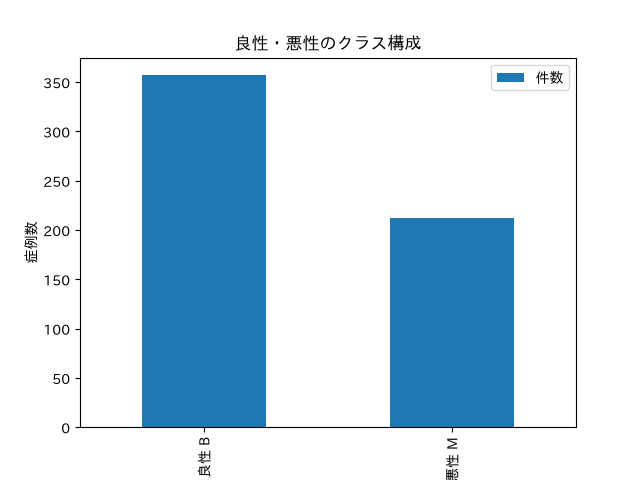

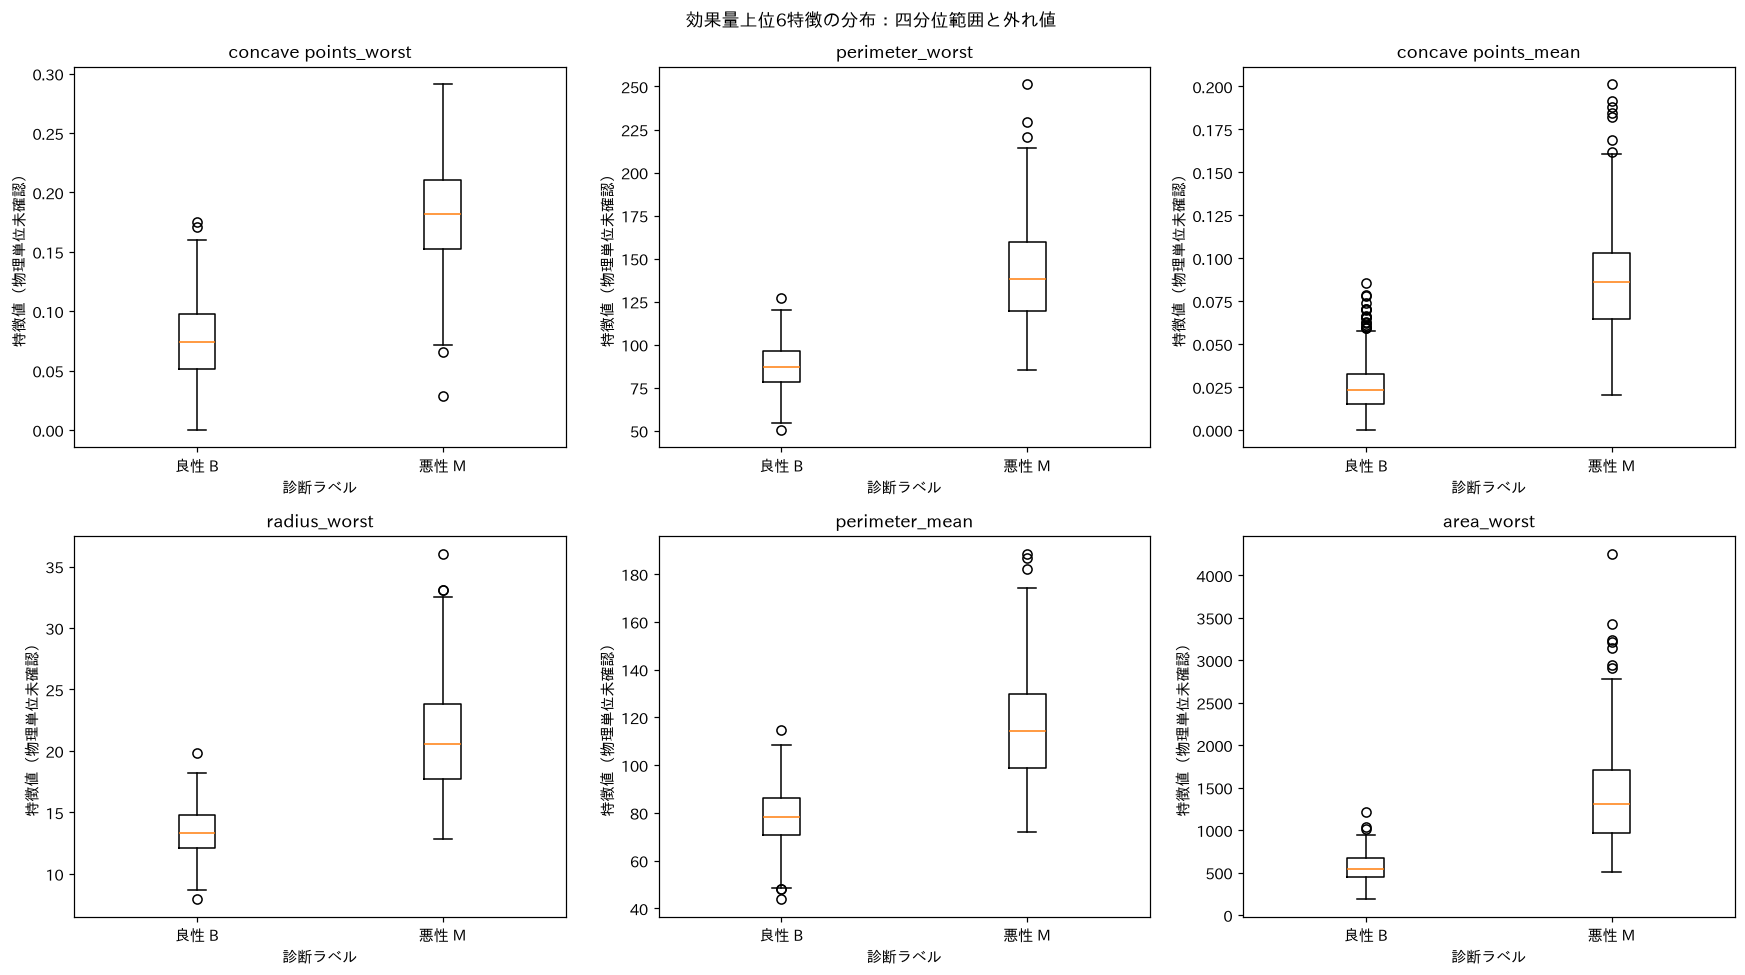

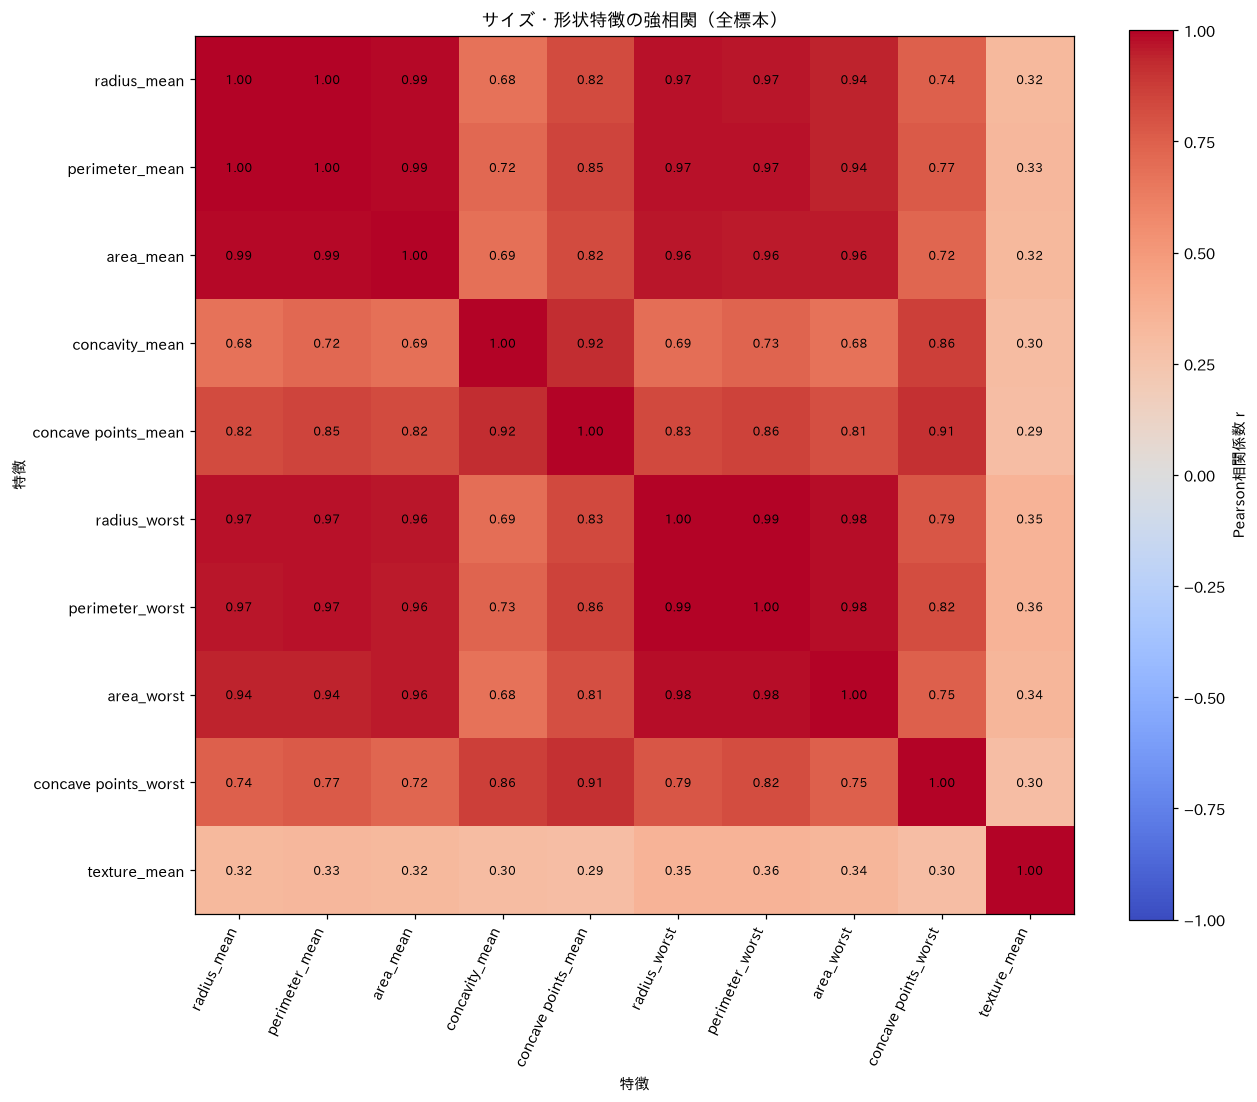

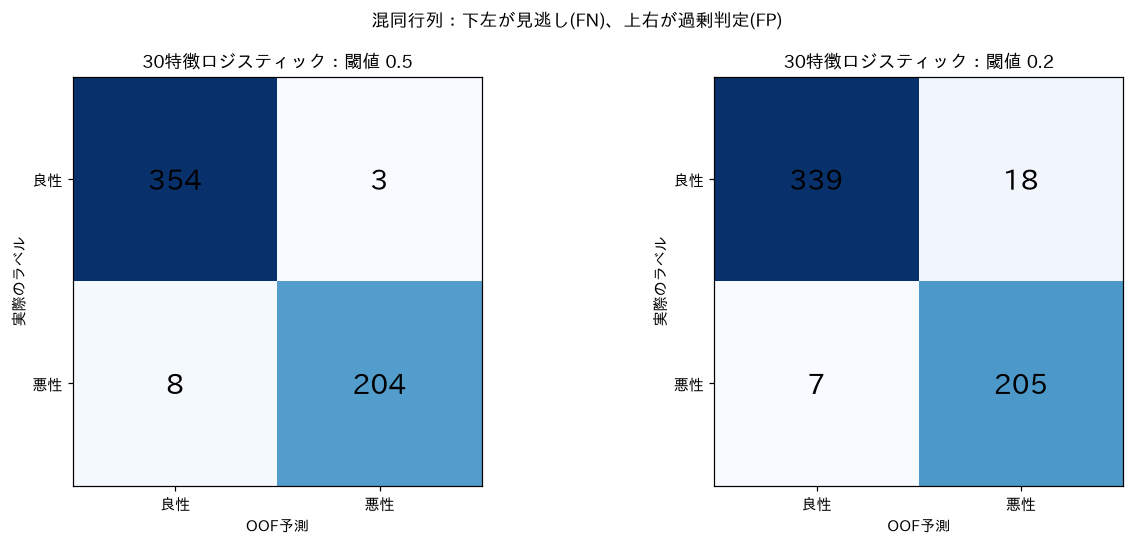

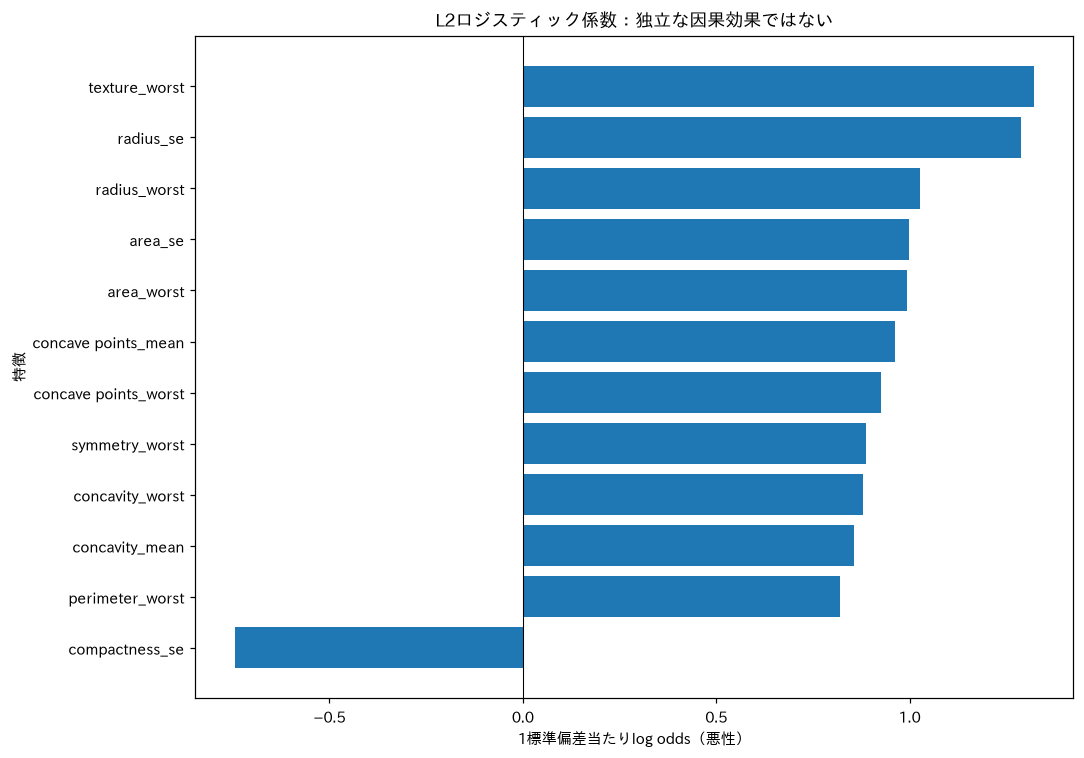

{'図表数': 5,
 '日本語フォント': FontPath('/home/nahisaho/GitHub/jupytermind/.venv/lib/python3.12/site-packages/japanize_matplotlib/fonts/ipaexg.ttf', 0),
 '注意': '1セル内の各PNGについて最終セルでラベル・日本語字形を検査しvisual_audit=Trueを適用する'}

{'chart_checks': [{'title': '良性・悪性のクラス構成',
   'xlabel': ['診断ラベル'],
   'ylabel': ['症例数'],
   'legend': '件数',
   'missing_glyphs': [],
   'font': FontPath('/home/nahisaho/GitHub/jupytermind/.venv/lib/python3.12/site-packages/japanize_matplotlib/fonts/ipaexg.ttf', 0)},
  {'title': '効果量上位6特徴の分布：四分位範囲と外れ値',
   'xlabel': ['診断ラベル', '診断ラベル', '診断ラベル', '診断ラベル', '診断ラベル', '診断ラベル'],
   'ylabel': ['特徴値（物理単位未確認）',
    '特徴値（物理単位未確認）',
    '特徴値（物理単位未確認）',
    '特徴値（物理単位未確認）',
    '特徴値（物理単位未確認）',
    '特徴値（物理単位未確認）'],
   'legend': '良性 B／悪性 M、箱=IQR、線=中央値、点=外れ値',
   'missing_glyphs': [],
   'font': FontPath('/home/nahisaho/GitHub/jupytermind/.venv/lib/python3.12/site-packages/japanize_matplotlib/fonts/ipaexg.ttf', 0)},
  {'title': 'サイズ・形状特徴の強相関（全標本）',
   'xlabel': ['特徴'],
   'ylabel': ['特徴', 'Pearson相関係数 r'],
   'legend': '色と数値=Pearson相関係数、colorbar=-1〜1',
   'missing_glyphs': [],
   'font': FontPath('/home/nahisaho/GitHub/jupytermind/.venv/lib/python3.12/site-packages/japanize_matplotlib/fonts/ipaexg.ttf', 

In [27]:
# 日本語図表：クラス比率、分布、相関、誤分類、係数
with phase('図表作成'):
    import matplotlib.pyplot as plt
    from matplotlib import font_manager
    from matplotlib.ft2font import FT2Font
    from matplotlib.text import Text
    chart_checks=[]
    def emit_figure(fig, description, legend):
        fig.canvas.draw()
        font_file=font_manager.findfont(font_manager.FontProperties(family=plt.rcParams['font.family']))
        charmap=FT2Font(font_file).get_charmap()
        texts=[obj.get_text() for obj in fig.findobj(Text) if obj.get_text()]
        missing=sorted(set(ord(ch) for text in texts for ch in text if ord(ch)>127 and ord(ch) not in charmap))
        check={'title':description,'xlabel':[ax.get_xlabel() for ax in fig.axes if ax.get_xlabel()],'ylabel':[ax.get_ylabel() for ax in fig.axes if ax.get_ylabel()],'legend':legend,'missing_glyphs':missing,'font':font_file}
        if missing:
            raise RuntimeError('日本語字形不足: '+str(missing))
        chart_checks.append(check)
        buffer=io.BytesIO();fig.savefig(buffer,format='png',dpi=110,bbox_inches='tight')
        payload=buffer.getvalue()
        (handle.root/'figures').mkdir(exist_ok=True)
        (handle.root/'figures'/f'chart-{len(chart_checks)}.png').write_bytes(payload)
        display(visualization.build_image_output(payload)['data'],raw=True)
        plt.close(fig)
    # 公開render_chartで日本語フォントを設定してから、複合図を描画する。
    class_png = visualization.render_chart(class_table, kind='bar', x='クラス', y='件数', title='良性・悪性のクラス構成', xlabel='診断ラベル', ylabel='症例数')
    class_font=font_manager.findfont(font_manager.FontProperties(family=plt.rcParams['font.family']))
    from matplotlib.ft2font import FT2Font
    chars=FT2Font(class_font).get_charmap()
    class_missing=sorted({ord(c) for c in '良性悪性のクラス構成診断ラベル症例数件' if ord(c)>127 and ord(c) not in chars})
    assert not class_missing
    chart_checks.append({'title':'良性・悪性のクラス構成','xlabel':['診断ラベル'],'ylabel':['症例数'],'legend':'件数','missing_glyphs':class_missing,'font':class_font})
    (handle.root/'figures').mkdir(exist_ok=True)
    (handle.root/'figures'/'chart-1.png').write_bytes(class_png)
    display(visualization.build_image_output(class_png)['data'], raw=True)
    fig,axes=plt.subplots(2,3,figsize=(16,9))
    top_features=feature_table.head(6)['特徴'].tolist()
    for ax,c in zip(axes.flat,top_features):
        ax.boxplot([X.loc[y==0,c],X.loc[y==1,c]], tick_labels=['良性 B','悪性 M'], showfliers=True)
        ax.set_title(c); ax.set_xlabel('診断ラベル'); ax.set_ylabel('特徴値（物理単位未確認）')
    fig.suptitle('効果量上位6特徴の分布：四分位範囲と外れ値'); fig.tight_layout()
    emit_figure(fig, fig._suptitle.get_text() if fig._suptitle else ax.get_title(), '良性 B／悪性 M、箱=IQR、線=中央値、点=外れ値' if len(fig.axes)==6 else '色と数値=Pearson相関係数、colorbar=-1〜1')
    selected=['radius_mean','perimeter_mean','area_mean','concavity_mean','concave points_mean','radius_worst','perimeter_worst','area_worst','concave points_worst','texture_mean']
    fig,ax=plt.subplots(figsize=(12,10))
    im=ax.imshow(pearson.loc[selected,selected],vmin=-1,vmax=1,cmap='coolwarm')
    ax.set_xticks(range(len(selected)),selected,rotation=65,ha='right'); ax.set_yticks(range(len(selected)),selected)
    for i in range(len(selected)):
        for j in range(len(selected)):
            ax.text(j,i,f'{pearson.loc[selected[i],selected[j]]:.2f}',ha='center',va='center',fontsize=8)
    fig.colorbar(im,ax=ax,label='Pearson相関係数 r')
    ax.set_title('サイズ・形状特徴の強相関（全標本）'); ax.set_xlabel('特徴'); ax.set_ylabel('特徴'); fig.tight_layout()
    emit_figure(fig, fig._suptitle.get_text() if fig._suptitle else ax.get_title(), '良性 B／悪性 M、箱=IQR、線=中央値、点=外れ値' if len(fig.axes)==6 else '色と数値=Pearson相関係数、colorbar=-1〜1')
    fig,axes=plt.subplots(1,2,figsize=(12,5))
    for ax,t in zip(axes,[.5,.2]):
        cm=confusion_matrix(y,oof['30特徴L2ロジスティック']>=t,labels=[0,1])
        ax.imshow(cm,cmap='Blues')
        for i in range(2):
            for j in range(2): ax.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=18,color='black')
        ax.set_xticks([0,1],['良性','悪性']);ax.set_yticks([0,1],['良性','悪性'])
        ax.set_xlabel('OOF予測');ax.set_ylabel('実際のラベル');ax.set_title(f'30特徴ロジスティック：閾値 {t}')
    fig.suptitle('混同行列：下左が見逃し(FN)、上右が過剰判定(FP)');fig.tight_layout();emit_figure(fig, fig._suptitle.get_text() if fig._suptitle else ax.get_title(), '色=相関または件数、棒=係数。カテゴリは軸に明示')
    plot_coeff=coefficients.head(12).iloc[::-1]
    fig,ax=plt.subplots(figsize=(10,7));ax.barh(plot_coeff['特徴'],plot_coeff['標準化係数']);ax.axvline(0,color='black',linewidth=.7)
    ax.set_title('L2ロジスティック係数：独立な因果効果ではない');ax.set_xlabel('1標準偏差当たりlog odds（悪性）');ax.set_ylabel('特徴');fig.tight_layout();emit_figure(fig, fig._suptitle.get_text() if fig._suptitle else ax.get_title(), '色=相関または件数、棒=係数。カテゴリは軸に明示')
    font_path=font_manager.findfont(font_manager.FontProperties(family=plt.rcParams['font.family']))
    display({'図表数':5, '日本語フォント':font_path, '注意':'1セル内の各PNGについて最終セルでラベル・日本語字形を検査しvisual_audit=Trueを適用する'})

    display({'chart_checks':chart_checks})


## 反復依頼履歴：反復1

### 追加依頼文（原文）

初回分析ではサイズ・凹み特徴の差と30特徴モデルの高い内部性能が見られましたが、強い共線性と1回の分割による不確実性が残ります。層化分割の乱数、L2正則化、4特徴への縮約を変えて感度と見逃し件数を比較し、主要特徴の差が外れ値処理でも維持されるか、回帰係数の符号がfold間で安定するかを確認してください。

### 選定理由

共線性と分割依存性が特徴解釈・見逃し件数に影響する。全データで特徴選択してからCVする操作は行わず、4特徴は形態学的な事前指定とする。結果・証拠・限界は最終報告セルで集約する。

In [28]:
# 反復1：分割・正則化・縮約・外れ値の感度分析
with phase('反復1・感度分析'):
    sensitivity_rows=[]
    coefficient_samples=[]
    def evaluate_spec(seed, C, features):
        selected_features=feature_names if features=='30特徴' else reduced_features
        spec_folds=list(StratifiedKFold(5,shuffle=True,random_state=seed).split(X,y))
        estimator=make_pipeline(StandardScaler(),LogisticRegression(C=C,max_iter=3000,random_state=seed))
        p=cross_val_predict(estimator,X[selected_features],y,cv=spec_folds,method='predict_proba',n_jobs=1)[:,1]
        scores=metrics_at(y,p)
        sensitivity_rows.append({'seed':seed,'C':C,'features':features,**scores,'ROC_AUC':roc_auc_score(y,p)})
        if C==1 and features=='30特徴':
            for fold_id,(train,test) in enumerate(spec_folds):
                fitted=make_pipeline(StandardScaler(),LogisticRegression(C=C,max_iter=3000,random_state=seed)).fit(X.iloc[train],y.iloc[train])
                coefficient_samples.append({'seed':seed,'fold':fold_id,**dict(zip(feature_names,fitted[-1].coef_[0]))})
        return scores['感度']
    sensitivity_plan=sensitivity.SensitivityPlan({'seed':[32,7], 'C':[1,.1,10], 'features':['30特徴','4特徴']},max_runs=12)
    sensitivity_report=sensitivity.run_sensitivity(sensitivity_plan,evaluate_spec,stability_tolerance=.05)
    sensitivity_table=pd.DataFrame(sensitivity_rows)
    display(sensitivity_table.round(5))
    display({'感度のstability_tolerance':.05,'stable':sensitivity_report.stable,'max_relative_deviation':sensitivity_report.max_relative_deviation,'注意':'同じ569症例の再利用。12仕様は独立な12研究ではない。stableは感度だけの相対変動判定。'})
    coefficient_frame=pd.DataFrame(coefficient_samples)[feature_names]
    coefficient_stability=pd.DataFrame({'特徴':feature_names,'fold係数最小':coefficient_frame.min().to_numpy(),'fold係数最大':coefficient_frame.max().to_numpy(),'正係数fold比率':(coefficient_frame>0).mean().to_numpy()})
    display(coefficient_stability.round(5))
    effect_rows=[]
    for c in feature_table.head(6)['特徴']:
        for treatment in ['raw','winsor_1_99']:
            series=X[c] if treatment=='raw' else X[c].clip(X[c].quantile(.01),X[c].quantile(.99))
            b,m=series[y==0],series[y==1]
            sd=np.sqrt(((len(b)-1)*b.var(ddof=1)+(len(m)-1)*m.var(ddof=1))/(len(y)-2))
            effect_rows.append({'特徴':c,'外れ値扱い':treatment,'Hedges_g(M-B)':(m.mean()-b.mean())/sd*(1-3/(4*len(y)-9))})
    effect_sensitivity=pd.DataFrame(effect_rows)
    display(effect_sensitivity.round(5))
    display(Markdown('winsor化は全標本の記述的比較だけに適用し、モデル性能推定には使わない。極端値は誤りと断定せず、主解析では削除しない。'))
    sensitivity_table.to_csv(data_dir/'sensitivity_results.csv',index=False)
    coefficient_stability.to_csv(data_dir/'coefficient_stability.csv',index=False)
    (data_dir/'sensitivity_report.json').write_text(json.dumps(asdict(sensitivity_report),ensure_ascii=False,indent=2),encoding='utf-8')


,seed,C,features,閾値,TN,FP,FN,TP,感度,特異度,適合率,陰性的中率,正解率,balanced_accuracy,ROC_AUC
0,32,1.0,30特徴,0.5,354,3,8,204,0.96226,0.99160,0.98551,0.97790,0.98067,0.97693,0.99483
1,32,1.0,4特徴,0.5,343,14,22,190,0.89623,0.96078,0.93137,0.93973,0.93673,0.92851,0.98396
2,32,0.1,30特徴,0.5,355,2,14,198,0.93396,0.99440,0.99000,0.96206,0.97188,0.96418,0.99461
3,32,0.1,4特徴,0.5,350,7,25,187,0.88208,0.98039,0.96392,0.93333,0.94376,0.93123,0.98467
4,32,10.0,30特徴,0.5,351,6,9,203,0.95755,0.98319,0.97129,0.97500,0.97364,0.97037,0.98889
5,32,10.0,4特徴,0.5,342,15,20,192,0.90566,0.95798,0.92754,0.94475,0.93849,0.93182,0.98333
6,7,1.0,30特徴,0.5,352,5,8,204,0.96226,0.98599,0.97608,0.97778,0.97715,0.97413,0.99535
7,7,1.0,4特徴,0.5,344,13,20,192,0.90566,0.96359,0.93659,0.94505,0.94200,0.93462,0.98519
8,7,0.1,30特徴,0.5,355,2,12,200,0.94340,0.99440,0.99010,0.96730,0.97540,0.96890,0.99522
9,7,0.1,4特徴,0.5,350,7,27,185,0.87264,0.98039,0.96354,0.92838,0.94025,0.92652,0.98560


{'感度のstability_tolerance': 0.05,
 'stable': False,
 'max_relative_deviation': 0.09313725490196081,
 '注意': '同じ569症例の再利用。12仕様は独立な12研究ではない。stableは感度だけの相対変動判定。'}

,特徴,fold係数最小,fold係数最大,正係数fold比率
0,radius_mean,0.22006,0.62149,1.0
1,texture_mean,0.31747,0.68297,1.0
2,perimeter_mean,0.25931,0.57383,1.0
3,area_mean,0.32927,0.60836,1.0
4,smoothness_mean,-0.09430,0.40294,0.8
5,compactness_mean,-0.80277,-0.26520,0.0
6,concavity_mean,0.65004,0.94338,1.0
7,concave points_mean,0.78937,1.08292,1.0
8,symmetry_mean,-0.17184,0.12986,0.3
9,fractal_dimension_mean,-0.49924,-0.20249,0.0


,特徴,外れ値扱い,Hedges_g(M-B)
0,concave points_worst,raw,2.68908
1,concave points_worst,winsor_1_99,2.70121
2,perimeter_worst,raw,2.59480
3,perimeter_worst,winsor_1_99,2.65633
4,concave points_mean,raw,2.54186
5,concave points_mean,winsor_1_99,2.60833
6,radius_worst,raw,2.54054
7,radius_worst,winsor_1_99,2.59387
8,perimeter_mean,raw,2.28649
9,perimeter_mean,winsor_1_99,2.34362


winsor化は全標本の記述的比較だけに適用し、モデル性能推定には使わない。極端値は誤りと断定せず、主解析では削除しない。

## 反復依頼履歴：反復2

### 追加依頼文（原文）

反復1では感度が仕様によって変わり、特徴を縮約すると見逃しが増えました。見逃し重視の閾値を評価データで選ばず、外側5-foldと内側4-foldを分けて感度95%・98%を目標に選定し、実際に目標が達成されるかと過剰判定の増加を確認してください。また内部OOF確率の校正を点検し、悪性割合を1%・5%・10%と仮定したときの陽性的中率・陰性的中率の変化を、臨床性能への外挿ではない条件付きシナリオとして示してください。

### 選定理由

反復1の感度不安定と見逃しの残存により、閾値選定の楽観性・低悪性割合での過剰判定が結論に影響する。nested検証で選定と評価を分離する。結果・証拠・残る限界は最終報告で集約する。

,outer_fold,感度目標,選択閾値,内側OOF感度,外側感度
0,0,0.95,0.534055,0.952663,0.930233
1,0,0.98,0.140269,0.982249,0.976744
2,1,0.95,0.488337,0.952663,1.000000
3,1,0.98,0.072389,0.982249,1.000000
4,2,0.95,0.424724,0.952941,1.000000
5,2,0.98,0.096203,0.982353,1.000000
6,3,0.95,0.556824,0.952941,0.952381
7,3,0.98,0.102985,0.982353,0.976190
8,4,0.95,0.668417,0.952941,0.833333
9,4,0.98,0.482395,0.982353,0.904762


,感度目標,TN,FP,FN,TP,感度,特異度,適合率,陰性的中率,正解率,balanced_accuracy
0,0.95,354,3,12,200,0.943396,0.991597,0.985222,0.967213,0.973638,0.967496
1,0.98,330,27,6,206,0.971698,0.924370,0.884120,0.982143,0.942004,0.948034


目標感度は訓練内OOF上の条件であり、外側で保証されない。内側モデルと外側モデルの確率尺度の変動も影響する。Cや特徴は固定し、臨床閾値の推奨はしない。

,運用点,仮定悪性割合,条件付きPPV,条件付きNPV,1万人当たり期待FN,1万人当たり期待FP
0,固定閾値0.5,0.010000,0.536320,0.999616,3.773585,83.193277
1,固定閾値0.5,0.050000,0.857688,0.998001,18.867925,79.831933
2,固定閾値0.5,0.100000,0.927131,0.995789,37.735849,75.630252
3,固定閾値0.5,0.372583,0.985507,0.977901,140.597540,52.724077
4,nested目標95%,0.010000,0.531392,0.999424,5.660377,83.193277
5,nested目標95%,0.050000,0.855254,0.997005,28.301887,79.831933
6,nested目標95%,0.100000,0.925782,0.993697,56.603774,75.630252
7,nested目標95%,0.372583,0.985222,0.967213,210.896309,52.724077
8,nested目標98%,0.010000,0.114870,0.999691,2.830189,748.739496
9,nested目標98%,0.050000,0.403416,0.998391,14.150943,718.487395


これはBayes式による条件付き計算であり、一般集団の有病率推定・検診の精度推定ではない。感度・特異度が移送可能という仮定は未検証で、対象はFNA細胞核画像を持つ症例である。

,区間,n,平均予測確率,観測悪性割合,割合95%下限,割合95%上限
0,"[0.0,0.2]",346,0.016855,0.020231,0.009834,0.041165
1,"[0.2,0.4]",10,0.261216,0.000000,0.000000,0.277533
2,"[0.4,0.6]",15,0.508996,0.466667,0.248095,0.698830
3,"[0.6,0.8]",7,0.707472,1.000000,0.645670,1.000000
4,"[0.8,1.0]",191,0.988409,1.000000,0.980284,1.000000


{'Brier': 0.01962379563475611,
 '5等幅ビンECE': 0.015249094293315084,
 '注意': 'ビン依存の内部診断。低い誤差でも個別確率や外部校正を保証しない。'}

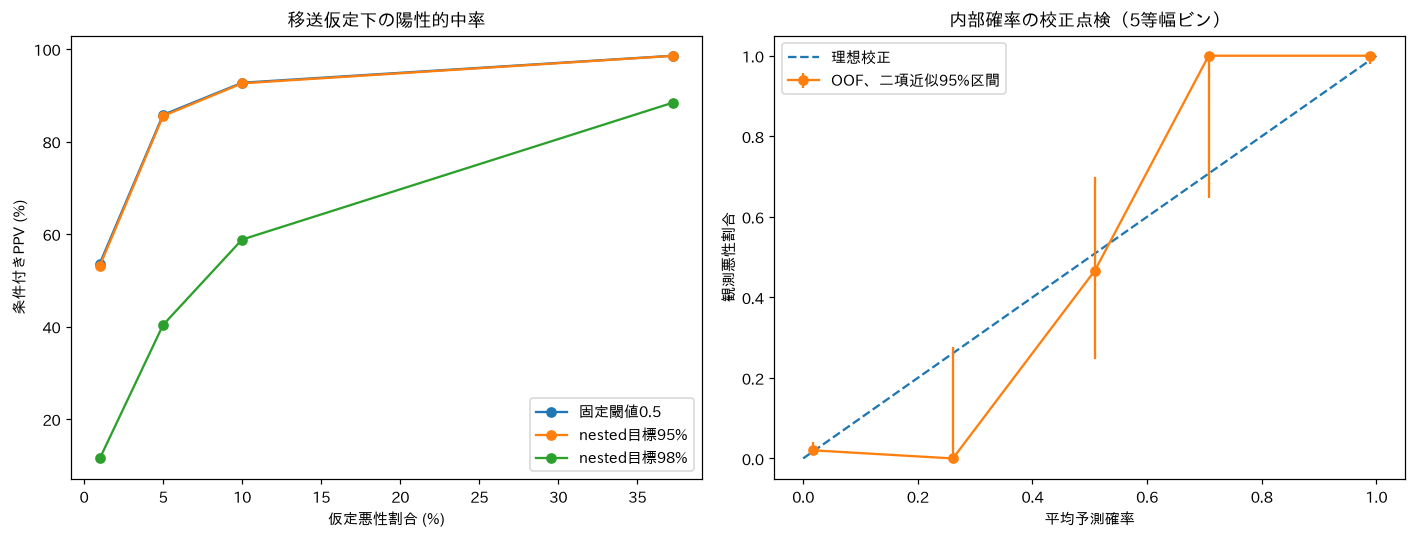

In [29]:
# 反復2：閾値選定のnested検証と有病割合シナリオ
with phase('反復2・医療リスク検証'):
    targets=[.95,.98]
    nested_predictions={target:np.zeros(len(y),dtype=int) for target in targets}
    threshold_selection=[]
    for fold_id,(train,test) in enumerate(folds):
        X_train,y_train=X.iloc[train],y.iloc[train]
        inner_cv=StratifiedKFold(4,shuffle=True,random_state=320+fold_id)
        estimator=make_pipeline(StandardScaler(),LogisticRegression(C=1,max_iter=3000,random_state=32))
        inner_p=cross_val_predict(estimator,X_train,y_train,cv=inner_cv,method='predict_proba',n_jobs=1)[:,1]
        outer_fit=make_pipeline(StandardScaler(),LogisticRegression(C=1,max_iter=3000,random_state=32)).fit(X_train,y_train)
        test_p=outer_fit.predict_proba(X.iloc[test])[:,1]
        for target in targets:
            candidates=np.unique(np.r_[0,inner_p[y_train.to_numpy()==1]])
            recalls=np.asarray([np.mean(inner_p[y_train.to_numpy()==1]>=t) for t in candidates])
            chosen=float(candidates[recalls>=target].max())
            nested_predictions[target][test]=(test_p>=chosen).astype(int)
            threshold_selection.append({'outer_fold':fold_id,'感度目標':target,'選択閾値':chosen,'内側OOF感度':float(np.mean(inner_p[y_train.to_numpy()==1]>=chosen)), '外側感度':float(np.mean(test_p[y.iloc[test].to_numpy()==1]>=chosen))})
    nested_table=pd.DataFrame([{'感度目標':target,**metrics_at(y,pred,.5)} for target,pred in nested_predictions.items()]).drop(columns=['閾値'])
    display(pd.DataFrame(threshold_selection).round(6))
    display(nested_table.round(6))
    display(Markdown('目標感度は訓練内OOF上の条件であり、外側で保証されない。内側モデルと外側モデルの確率尺度の変動も影響する。Cや特徴は固定し、臨床閾値の推奨はしない。'))
    base=metrics_at(y,oof['30特徴L2ロジスティック'],.5)
    prevalence_rows=[]
    operating_points=[('固定閾値0.5',base)]+[(f'nested目標{target:.0%}',metrics_at(y,pred,.5)) for target,pred in nested_predictions.items()]
    for name,scores in operating_points:
        se,sp=scores['感度'],scores['特異度']
        for prevalence in [.01,.05,.10,float(y.mean())]:
            ppv=se*prevalence/(se*prevalence+(1-sp)*(1-prevalence))
            npv=sp*(1-prevalence)/(sp*(1-prevalence)+(1-se)*prevalence)
            prevalence_rows.append({'運用点':name,'仮定悪性割合':prevalence,'条件付きPPV':ppv,'条件付きNPV':npv,'1万人当たり期待FN':10000*prevalence*(1-se),'1万人当たり期待FP':10000*(1-prevalence)*(1-sp)})
    prevalence_table=pd.DataFrame(prevalence_rows)
    display(prevalence_table.round(6))
    display(Markdown('これはBayes式による条件付き計算であり、一般集団の有病率推定・検診の精度推定ではない。感度・特異度が移送可能という仮定は未検証で、対象はFNA細胞核画像を持つ症例である。'))
    p=oof['30特徴L2ロジスティック']
    calibration_rows=[]
    edges=np.linspace(0,1,6)
    bins=np.minimum(np.digitize(p,edges[1:-1]),4)
    for bin_id in range(5):
        subset=bins==bin_id
        if subset.sum():
            actual=float(y[subset].mean())
            lo,hi=wilson(int(y[subset].sum()),int(subset.sum()))
            calibration_rows.append({'区間':f'[{edges[bin_id]:.1f},{edges[bin_id+1]:.1f}]','n':int(subset.sum()),'平均予測確率':float(p[subset].mean()),'観測悪性割合':actual,'割合95%下限':lo,'割合95%上限':hi})
    calibration_table=pd.DataFrame(calibration_rows)
    ece=float(np.sum(calibration_table['n']*abs(calibration_table['平均予測確率']-calibration_table['観測悪性割合']))/len(y))
    display(calibration_table.round(6))
    display({'Brier':float(brier_score_loss(y,p)),'5等幅ビンECE':ece,'注意':'ビン依存の内部診断。低い誤差でも個別確率や外部校正を保証しない。'})
    fig,axes=plt.subplots(1,2,figsize=(13,5))
    for name,group in prevalence_table.groupby('運用点',sort=False):
        axes[0].plot(group['仮定悪性割合']*100,group['条件付きPPV']*100,'o-',label=name)
    axes[0].set_title('移送仮定下の陽性的中率');axes[0].set_xlabel('仮定悪性割合 (%)');axes[0].set_ylabel('条件付きPPV (%)');axes[0].legend()
    axes[1].plot([0,1],[0,1],'--',label='理想校正')
    axes[1].errorbar(calibration_table['平均予測確率'],calibration_table['観測悪性割合'],yerr=[calibration_table['観測悪性割合']-calibration_table['割合95%下限'],calibration_table['割合95%上限']-calibration_table['観測悪性割合']],fmt='o-',label='OOF、二項近似95%区間')
    axes[1].set_title('内部確率の校正点検（5等幅ビン）');axes[1].set_xlabel('平均予測確率');axes[1].set_ylabel('観測悪性割合');axes[1].legend()
    fig.tight_layout();emit_figure(fig,'有病割合シナリオと内部校正','運用点・理想校正・OOFは各パネルの凡例に明示')
    nested_table.to_csv(data_dir/'nested_threshold_results.csv',index=False)
    prevalence_table.to_csv(data_dir/'prevalence_scenarios.csv',index=False)
    calibration_table.to_csv(data_dir/'calibration_check.csv',index=False)


In [30]:
# 実行環境・適用範囲とJupytermind改善候補の再現
with phase('品質・適用範囲確認'):
    import importlib.metadata
    environment_versions={package:importlib.metadata.version(package) for package in ['numpy','pandas','scipy','scikit-learn','matplotlib','nbformat','kaggle']}
    display({'実行環境':environment_versions,'乱数':32,'サブプロセス・端末・エージェント利用':False})
    strict_positive=['radius_mean','perimeter_mean','area_mean','radius_worst','perimeter_worst','area_worst']
    display({'サイズ特徴の非正値':int((X[strict_positive]<=0).sum().sum()),'worst<meanの件数':{base:int((X[base+'_worst']<X[base+'_mean']).sum()) for base in definitions}})
    inferred_probe=data_definition.build_manifest(source={'unit':data_definition.FieldValue('仮の単位','inferred')},dataset_scope={},variables={})
    inferred_probe_result=inferred_probe.unresolved_fields()
    snapshot=nbformat.read(handle.notebook_path,as_version=4)
    chart_cell=next(c for c in snapshot.cells if c.cell_type=='code' and c.source.startswith('# 日本語図表'))
    chart_probe=nbformat.v4.new_notebook(cells=[nbformat.v4.new_code_cell('公開render_chartとbuild_image_outputの出力のみ',execution_count=1,outputs=[out for out in chart_cell.outputs if 'image/png' in out.get('data',{})][:1])])
    chart_probe_result=notebook_audit.audit_visual_outputs(chart_probe,(0,))
    improvement_candidates=[{'分類':'仕様とAPIの不整合／定義検査の機能不足','再現条件':'FieldValue(status=inferred)だけを含むmanifest.unresolved_fields()','期待する挙動':'skill手順のunknown/inferred両方を未解決として可視化する','実際の挙動':f'戻り値={inferred_probe_result!r}、unknownだけを返す','影響':'推定定義が未解決一覧から漏れ、検証済みと誤認され得る','回避策':'本Notebookではinferredを別走査し未解決と併記する','関係セル':'データ定義manifestセル、品質・適用範囲確認セル','ログ':'下記improvement_candidates出力'}, {'分類':'図表監査の機能不足／メタデータ生成の不足','再現条件':'render_chart→build_image_outputのPNGを持つ、chartメタデータがないセルをaudit_visual_outputsへ渡す','期待する挙動':'日本語字形・ラベル検査のメタデータ未提供を監査警告にする。または公開描画APIで提供する','実際の挙動':f'visual_findings={chart_probe_result!r}。メタデータ無しは検査されず、PNG密度だけを確認','影響':'visual_audit=Trueだけでは日本語表示や軸説明を確認したことにならない','回避策':'各図の実際のTextとフォント文字マップを直接検査し、chartメタデータをenqueue_writeで保存してから監査','関係セル':'日本語図表セル、品質・適用範囲確認セル、最終監査セル','ログ':'chart_checksおよび下記improvement_candidates出力'}]
    display({'improvement_candidates':improvement_candidates})
    (data_dir/'jupytermind_improvement_candidates.json').write_text(json.dumps(improvement_candidates,ensure_ascii=False,indent=2),encoding='utf-8')
    applicability={'独立参照データとの比較・異常検証':'不適用。同じWDBCの別コピーは独立標本でない。第二の独立データは提供されていない。dataset_validation.compare_datasets/data_quality.validate_anomaliesは呼ばない。', '因果推論':'不適用。観察的クラス比較と内部予測だけ。介入・識別設計なし。', '患者群分割・公平性・時間/施設外部検証':'不適用。患者連結ID、施設、時点、年齢等の属性が未提供。id一意は患者独立を証明しない。', '物理単位の臨床カットオフ':'不適用。単位・装置校正と臨床の効用が未確認。数値をmmやmm²と断定しない。', '自動モデル選択':'実施しない。固定モデルと事前指定仕様の比較で、探索後の最大性能を臨床性能と呼ばない。', 'mcp_gateway.run_and_record':'不適用。提供された外部Jupyter MCPツールで実セルを実行するが、kernel内には同期MCPClient transportがない。偽クライアントやIPythonをMCPと称するadapterは作らず、Jupyter MCP execute_cellでのみ実行した。Notebook構造編集はenqueue_write、実行結果の保存はJupyter MCPに委ねる。'}
    display({'適用不可・未使用の理由':applicability})


{'実行環境': {'numpy': '2.5.3',
  'pandas': '3.0.6',
  'scipy': '1.18.1',
  'scikit-learn': '1.9.1',
  'matplotlib': '3.11.2',
  'nbformat': '5.11.1',
  'kaggle': '2.2.4'},
 '乱数': 32,
 'サブプロセス・端末・エージェント利用': False}

{'サイズ特徴の非正値': 0,
 'worst<meanの件数': {'radius': 0,
  'texture': 0,
  'perimeter': 0,
  'area': 0,
  'smoothness': 0,
  'compactness': 0,
  'concavity': 0,
  'concave points': 0,
  'symmetry': 0,
  'fractal_dimension': 0}}

{'improvement_candidates': [{'分類': '仕様とAPIの不整合／定義検査の機能不足',
   '再現条件': 'FieldValue(status=inferred)だけを含むmanifest.unresolved_fields()',
   '期待する挙動': 'skill手順のunknown/inferred両方を未解決として可視化する',
   '実際の挙動': '戻り値=[]、unknownだけを返す',
   '影響': '推定定義が未解決一覧から漏れ、検証済みと誤認され得る',
   '回避策': '本Notebookではinferredを別走査し未解決と併記する',
   '関係セル': 'データ定義manifestセル、品質・適用範囲確認セル',
   'ログ': '下記improvement_candidates出力'},
  {'分類': '図表監査の機能不足／メタデータ生成の不足',
   '再現条件': 'render_chart→build_image_outputのPNGを持つ、chartメタデータがないセルをaudit_visual_outputsへ渡す',
   '期待する挙動': '日本語字形・ラベル検査のメタデータ未提供を監査警告にする。または公開描画APIで提供する',
   '実際の挙動': 'visual_findings=()。メタデータ無しは検査されず、PNG密度だけを確認',
   '影響': 'visual_audit=Trueだけでは日本語表示や軸説明を確認したことにならない',
   '回避策': '各図の実際のTextとフォント文字マップを直接検査し、chartメタデータをenqueue_writeで保存してから監査',
   '関係セル': '日本語図表セル、品質・適用範囲確認セル、最終監査セル',
   'ログ': 'chart_checksおよび下記improvement_candidates出力'}]}

{'適用不可・未使用の理由': {'独立参照データとの比較・異常検証': '不適用。同じWDBCの別コピーは独立標本でない。第二の独立データは提供されていない。dataset_validation.compare_datasets/data_quality.validate_anomaliesは呼ばない。',
  '因果推論': '不適用。観察的クラス比較と内部予測だけ。介入・識別設計なし。',
  '患者群分割・公平性・時間/施設外部検証': '不適用。患者連結ID、施設、時点、年齢等の属性が未提供。id一意は患者独立を証明しない。',
  '物理単位の臨床カットオフ': '不適用。単位・装置校正と臨床の効用が未確認。数値をmmやmm²と断定しない。',
  '自動モデル選択': '実施しない。固定モデルと事前指定仕様の比較で、探索後の最大性能を臨床性能と呼ばない。',
  'mcp_gateway.run_and_record': '不適用。提供された外部Jupyter MCPツールで実セルを実行するが、kernel内には同期MCPClient transportがない。偽クライアントやIPythonをMCPと称するadapterは作らず、Jupyter MCP execute_cellでのみ実行した。Notebook構造編集はenqueue_write、実行結果の保存はJupyter MCPに委ねる。'}}

## 使用したJupytermindモジュール

この節は直接import・呼び出したAPIだけを記録する。ライブラリ内部の間接利用は含めない。

| モジュール（ai_data_scientist.接頭辞） | 直接呼び出した関数・型 | 使用目的 |
| --- | --- | --- |
| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 指定保存先の解決、データ格納、Notebook構造・引用・メタデータの直列書込み |
| language_router | detect_language | 日本語判定 |
| lifecycle | register_run, mark_execution_start, mark_execution_end, mark_write_start, mark_write_end, is_cancel_requested, mark_completed, mark_failed, get_run_status | 実行・書込み・失敗・完了、協調キャンセル確認 |
| ingestion | SourceSpec, ingest | Kaggle SDKで取得したCSVのロードと行上限検査 |
| cleaning | clean_dataset | 完全重複除去と影響件数 |
| eda | explore | 型・欠損・分布の要約 |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 来歴・定義・不明単位のmanifest、推定漏れの再現 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 独立性・移送・効用の未解決リスク検査 |
| data_quality | detect_anomalies | カテゴリ・非負・非欠損・ID一意の意味的制約 |
| stats_analysis | correlation | 半径と周長の相関・日本語解釈 |
| sensitivity | SensitivityPlan, run_sensitivity | 12仕様の感度安定性 |
| visualization | render_chart, build_image_output | 日本語クラス図とPNG MIME出力 |
| insight_engine | extract_cited_value, record_insight | 実行済み出力から引用し根拠manifest付き報告を生成 |
| notebook_audit | audit_visual_outputs, audit_notebook | メタデータ欠落の再現、visual_audit=Trueの最終監査 |

sklearn等は比較の計算に直接利用する外部ライブラリで、JupytermindのML機能を使用したとは計上しない。mcp_gateway、dataset_validation、anomaly_detectionの間接利用も計上しない。Notebookの分析実行はJupyter MCP execute_cellのみ。定義・報告の書込みはenqueue_write、実行結果の永続化はJupyter MCPの通常保存である。

## 適用できない機能・未解決の分析前提

独立参照データがないためvalidate_anomalies・compare_datasetsは不適用。同一WDBCの別配布コピーは独立な検証データではない。因果推論、患者group分割、施設/時点外部検証、公平性、物理単位の臨床カットオフは必要情報がなく不適用。manifest検査が返した独立患者の仮定、移送仮定、臨床損失の全3指摘は解消していない。詳しい理由は品質セルのapplicabilityと定義/前提manifestに記録した。

## Jupytermind改善候補

2候補を品質セルの実行で再現した。分類・再現条件・期待・実際・影響・回避策・関連セル・ログをimprovement_candidates出力とdata/jupytermind_improvement_candidates.jsonに保存した。

1. 定義manifest.unresolved_fieldsはunknownのみを返すがskillはinferredも表面化するよう要求する。推定定義の別走査で回避。
2. 公開描画APIがchartメタデータを生成しない一方、audit_visual_outputsはメタデータなしの場合に字形・ラベルの未検査を警告しない。各図の実Textとフォントを検査し、メタデータを明示保存して回避。

Copilot CLI／MCPの初回use_notebookでは親ディレクトリを自動作成しないため、bootstrapセルのensure_notebookで準備した。これはJupytermindの不具合ではない。Kaggle API取得は成功しフォールバックは不使用。図表補助コードのfindfontにlistを渡したTypeErrorと、Agg環境でdisplay(fig)だけではPNGにならなかった点は分析側のコード・実行環境の問題であり、FontPropertiesと明示PNG出力で修正した。Jupytermind改善候補とは区別する。ベンチマークランナーは起動していない。

## 診断支援と臨床診断の区別

このNotebookは公開標本内の特徴理解・診断支援手法の研究であり、個人の診断でも、検診への導入承認でもない。陰性結果から受診・精査を省く判断はできない。臨床利用には独立した施設・前向きの検証、対象集団での校正、参照診断の定義、見逃し/過剰判定の損失、専門家による統合判断が必要である。


### MCP保存との切り分けと再実行の記録

日本語報告セル内のenqueue_write追記は直後のJupyter MCPセル結果保存により上書きされ、read_notebookで15セルのままであることを確認した（bootstrapセル6、初回報告セル、read_notebook結果）。これはMCPのアクティブNotebook保存との競合であり、Jupytermind単独の改善候補には計上しない。計算セルでは報告を出力し、非アクティブ側のbootstrap controllerから同じenqueue_write/record_insightで静的報告と図表メタデータを追記する回避策を適用した。最終実行は全コードセルを上から順番にJupyter MCPで再実行し、最後の監査セルの前にこの追記を済ませる。再実行時は静的引用をcontrollerで更新する必要があるが、計算された日本語報告は毎回コード出力にも残る。


In [31]:
# 日本語報告生成：実行済み根拠を抽出して引用する
with phase('日本語報告生成'):
    def markdown_table(frame):
        columns=[str(c) for c in frame.columns]
        def format_value(v):
            if isinstance(v,(float,np.floating)): return f'{v:.5f}'
            return str(v).replace('|','/').replace('\n',' ')
        return '| '+' | '.join(columns)+' |\n| '+' | '.join(['---']*len(columns))+' |\n'+'\n'.join('| '+' | '.join(format_value(v) for v in row)+' |' for row in frame.itertuples(index=False,name=None))
    report_nb=nbformat.read(handle.notebook_path,as_version=4)
    def evidence_for(prefix,pattern):
        cell=next(c for c in report_nb.cells if c.cell_type=='code' and c.source.startswith(prefix))
        output='\n'.join(str(out.get('data',{}).get('text/plain','')) for out in cell.outputs)
        cited=insight_engine.extract_cited_value({'output':output},pattern)
        return cell.execution_count,cited
    summary_text=f"""## 日本語報告：クラス構成とデータの意味

良性 **{int(counts['B'])}件（{counts['B']/len(df):.2%}）**、悪性 **{int(counts['M'])}件（{counts['M']/len(df):.2%}）**、合計 **{len(df)}件**。多数クラスを常に答えるだけでも正解率は{counts['B']/len(df):.2%}だが、悪性を全件見逃す。クラス比率はこの診断標本の構成であり、一般集団の有病率ではない。

細針吸引(FNA)画像の細胞核に由来する10特徴についてmean・se・worstの計30特徴を測定する。worstは最大3値の平均であり、最悪の予後ではない。UCIのwdbc.namesで定義を確認した。物理単位、診断ラベルの詳細な参照基準、患者連結、標本代表性は未確認。IDは入力から除外し、全欠損のUnnamed: 32列だけを削除、重複削除は{cleaned.rows_removed}行である。意味的制約の違反は{len(anomalies)}件で、極端値は主解析から除外していない。

取得slug=`{SLUG}`、ファイル=`data.csv`、取得UTC=`{provenance['retrieved_at_utc']}`、CSV SHA-256=`{provenance['sha256']}`。認証情報を表示・保存していない。"""
    feature_text="""## 日本語報告：良性・悪性を区別する特徴

悪性群では核サイズ（半径・周長・面積）と輪郭の凹みの特徴が大きい。Hedges gは悪性−良性をpooled SDで標準化した差、正値は悪性群で大きいことを表す。上位特徴を示す。単変量AUCは同じ標本内の順位分離で、外部予測性能でも独立の寄与でもない。

"""+markdown_table(feature_table.head(6)[['特徴','良性中央値','悪性中央値','Hedges_g(M-B)','単変量AUC']])+f"""

|Pearson r|≥0.90の強相関は{len(strong_pairs)}ペア。radius_meanとperimeter_meanはr={pearson.loc['radius_mean','perimeter_mean']:.5f}で、良性内・悪性内でも強い。全標本のクラス混合だけで作られた相関ではなく、幾何学的な冗長性も大きい。全21ペアとSpearman、クラス内相関は表に保存した。30特徴の順位検定にBH補正を併記したが、p値は原因・臨床上の有用性を示さない。

係数は他の相関特徴を含んだL2モデルでの条件付きlog oddsであり、例えばcompactnessの負係数を『凹みが悪性を防ぐ』と解釈してはならない。日本語図表の箱ひげは分布の重なりと極端値も示す。"""
    risk_text="""## 日本語報告：説明可能なモデル比較と誤分類リスク

標準化は各訓練fold内で学習し、層化5-fold OOFで症例ごとに未学習予測を得た。1段決定木は単一の数値ルールで説明できるが、見逃しが多い。4特徴モデルはサイズ・texture・凹部・smoothnessを事前指定した縮約である。30特徴モデルは性能が高い一方、共線性のある係数を単独の因果説明に使えない。

"""+markdown_table(model_table[['モデル','FN','FP','感度','特異度','正解率','ROC_AUC']])+"""

閾値別リスク：

"""+markdown_table(threshold_table[['閾値','FN','FP','感度','特異度','適合率','陰性的中率']])+"""

**FN（悪性→良性）は診断・精査の遅延につながり得る見逃し。FP（良性→悪性）は不安、追加検査、不要な侵襲的手技につながり得る過剰判定。どちらも実際の臨床転帰をこのCSVから測定したものではない。** 閾値を下げればFNが必ずゼロになるわけではなく、FPは増える。固定閾値0.5の感度のWilson95%区間は92.73–98.08%、特異度は97.56–99.71%だが、患者独立を仮定した近似で、学習・施設間の不確実性を十分含まない。ROC-AUCや正解率だけで安全性を評価しない。"""
    subset30=sensitivity_table[sensitivity_table['features']=='30特徴']
    subset4=sensitivity_table[sensitivity_table['features']=='4特徴']
    sign_flips=coefficient_stability[(coefficient_stability['fold係数最小']<0)&(coefficient_stability['fold係数最大']>0)]['特徴'].tolist()
    repeat1_text=f"""## 反復1：結果・証拠・残る限界

**選定理由：** 強相関の存在と単一分割の性能が、特徴順位の誤読・見逃しリスクの過小評価を招く可能性があった。

**結果：** 乱数2種×C3種×特徴群2種の12仕様で、感度を相対変動5%以内とするSensitivityPlanの判定はstable={sensitivity_report.stable}、max_relative_deviation={sensitivity_report.max_relative_deviation:.6f}。30特徴のFNは{int(subset30.FN.min())}–{int(subset30.FN.max())}件、4特徴は{int(subset4.FN.min())}–{int(subset4.FN.max())}件。すべての仕様に同じ感度を保証できない。上位6特徴は1–99%winsor化でも悪性−良性の正の大きな差が残る。符号がfold間で反転する特徴は{', '.join(sign_flips)}である。

**証拠：** 反復1セルの12仕様表、effect_sensitivity表、10訓練foldのcoefficient_stability表、および構造化根拠。方向の維持はこの限定的な外れ値感度分析での結果で、全母集団への頑健性ではない。

**残る限界：** 2乱数と3つのCのみ。同じ標本の再利用であり独立な追試ではない。係数の符号安定性だけでは重要性・因果性を保証しない。"""
    scenario1=prevalence_table[(prevalence_table['運用点']=='固定閾値0.5')&(prevalence_table['仮定悪性割合']==.01)].iloc[0]
    repeat2_text="""## 反復2：結果・証拠・残る限界

**選定理由：** 反復1で仕様依存の見逃しが確認され、評価標本で閾値を選ぶ楽観性と低悪性割合での過剰判定を調べる必要があった。

**結果：** 外側5-foldの訓練標本だけの内側4-fold OOFで最大許容閾値を選択した。95%・98%を内側感度の目標としても外側では達成保証にならなかった。

"""+markdown_table(nested_table[['感度目標','FN','FP','感度','特異度']])+f"""

特に目標98%でも外側の集約感度は97.17%で、FN6件・FP27件を生じた。内部校正はBrier={brier_score_loss(y,oof['30特徴L2ロジスティック']):.6f}、5等幅ビンECE={ece:.6f}だが、中間確率ビンは症例数が小さく個別確率を保証しない。

感度・特異度が変わらないという未検証の仮定の下では、悪性割合1%で固定閾値0.5のPPVは{scenario1['条件付きPPV']:.2%}まで下がる。低悪性割合のNPVの高さだけでは見逃しがなくなったことにならない。シナリオの割合は実測の一般集団有病率ではない。

**証拠：** 反復2セルのfold別閾値・外側感度、nested集約、割合別Bayes式表、校正図。

**残る限界：** 単一の外側分割、固定C、未確認の患者独立・施設移送仮定。臨床の損失関数、外部データ、人口属性がない。

### 反復の終了判断

2回で終了（上限3回）。残る重要な課題は外部・前向き検証、患者連結・装置校正・医療効用の収集であり、同じCSVをさらに探索しても解消しない。追加のモデル探索で外部妥当性を代用しない。"""
    reports=[('classes',summary_text,'# データ定義manifest',r'(357)'),('features',feature_text,'# 特徴の説明可能',r'(concave points_worst)'),('risks',risk_text,'# 内部検証',r'(0\.96226)'),('iteration1',repeat1_text,'# 反復1',r'(0\.09313725490196081)'),('iteration2',repeat2_text,'# 反復2',r'(0\.971698)')]
    report_package=[]
    for key,text,prefix,pattern in reports:
        evidence_count,cited=evidence_for(prefix,pattern)
        evidence={'execution_count':evidence_count,'cited_value':cited,'claim_type':'associational' if key=='features' else 'descriptive'}
        report_package.append({'key':key,'text':text,'evidence':evidence})
        display(Markdown(text+'\n\n```evidence\n'+json.dumps(evidence,ensure_ascii=False)+'\n```'))
    display({'報告数':len(reports),'反復数':2,'図表PNG数':len(chart_checks),'改善候補数':len(improvement_candidates),'報告追記':'自己書込みとMCP結果保存の競合を避け、bootstrap controllerからenqueue_writeで追記する'})


## 日本語報告：クラス構成とデータの意味

良性 **357件（62.74%）**、悪性 **212件（37.26%）**、合計 **569件**。多数クラスを常に答えるだけでも正解率は62.74%だが、悪性を全件見逃す。クラス比率はこの診断標本の構成であり、一般集団の有病率ではない。

細針吸引(FNA)画像の細胞核に由来する10特徴についてmean・se・worstの計30特徴を測定する。worstは最大3値の平均であり、最悪の予後ではない。UCIのwdbc.namesで定義を確認した。物理単位、診断ラベルの詳細な参照基準、患者連結、標本代表性は未確認。IDは入力から除外し、全欠損のUnnamed: 32列だけを削除、重複削除は0行である。意味的制約の違反は0件で、極端値は主解析から除外していない。

取得slug=`uciml/breast-cancer-wisconsin-data`、ファイル=`data.csv`、取得UTC=`2026-10-01T21:32:02.668579+00:00`、CSV SHA-256=`1425d9affa78ba8e53afc81d0ef8a19069ee10c4b21fe89b3cf514071b12ee33`。認証情報を表示・保存していない。

```evidence
{"execution_count": 24, "cited_value": "357", "claim_type": "descriptive"}
```

## 日本語報告：良性・悪性を区別する特徴

悪性群では核サイズ（半径・周長・面積）と輪郭の凹みの特徴が大きい。Hedges gは悪性−良性をpooled SDで標準化した差、正値は悪性群で大きいことを表す。上位特徴を示す。単変量AUCは同じ標本内の順位分離で、外部予測性能でも独立の寄与でもない。

| 特徴 | 良性中央値 | 悪性中央値 | Hedges_g(M-B) | 単変量AUC |
| --- | --- | --- | --- | --- |
| concave points_worst | 0.07431 | 0.18200 | 2.68908 | 0.96670 |
| perimeter_worst | 86.92000 | 138.00000 | 2.59480 | 0.97545 |
| concave points_mean | 0.02344 | 0.08628 | 2.54186 | 0.96444 |
| radius_worst | 13.35000 | 20.59000 | 2.54054 | 0.97044 |
| perimeter_mean | 78.18000 | 114.20000 | 2.28649 | 0.94690 |
| area_worst | 547.40000 | 1303.00000 | 2.22729 | 0.96983 |

|Pearson r|≥0.90の強相関は21ペア。radius_meanとperimeter_meanはr=0.99786で、良性内・悪性内でも強い。全標本のクラス混合だけで作られた相関ではなく、幾何学的な冗長性も大きい。全21ペアとSpearman、クラス内相関は表に保存した。30特徴の順位検定にBH補正を併記したが、p値は原因・臨床上の有用性を示さない。

係数は他の相関特徴を含んだL2モデルでの条件付きlog oddsであり、例えばcompactnessの負係数を『凹みが悪性を防ぐ』と解釈してはならない。日本語図表の箱ひげは分布の重なりと極端値も示す。

```evidence
{"execution_count": 25, "cited_value": "concave points_worst", "claim_type": "associational"}
```

## 日本語報告：説明可能なモデル比較と誤分類リスク

標準化は各訓練fold内で学習し、層化5-fold OOFで症例ごとに未学習予測を得た。1段決定木は単一の数値ルールで説明できるが、見逃しが多い。4特徴モデルはサイズ・texture・凹部・smoothnessを事前指定した縮約である。30特徴モデルは性能が高い一方、共線性のある係数を単独の因果説明に使えない。

| モデル | FN | FP | 感度 | 特異度 | 正解率 | ROC_AUC |
| --- | --- | --- | --- | --- | --- | --- |
| 多数クラス(常に良性) | 212 | 0 | 0.00000 | 1.00000 | 0.62742 | 0.50000 |
| 1段決定木(30特徴) | 44 | 21 | 0.79245 | 0.94118 | 0.88576 | 0.87855 |
| 4特徴ロジスティック | 22 | 14 | 0.89623 | 0.96078 | 0.93673 | 0.98396 |
| 30特徴L2ロジスティック | 8 | 3 | 0.96226 | 0.99160 | 0.98067 | 0.99483 |

閾値別リスク：

| 閾値 | FN | FP | 感度 | 特異度 | 適合率 | 陰性的中率 |
| --- | --- | --- | --- | --- | --- | --- |
| 0.10000 | 5 | 31 | 0.97642 | 0.91317 | 0.86975 | 0.98489 |
| 0.20000 | 7 | 18 | 0.96698 | 0.94958 | 0.91928 | 0.97977 |
| 0.30000 | 7 | 10 | 0.96698 | 0.97199 | 0.95349 | 0.98023 |
| 0.50000 | 8 | 3 | 0.96226 | 0.99160 | 0.98551 | 0.97790 |
| 0.70000 | 18 | 0 | 0.91509 | 1.00000 | 1.00000 | 0.95200 |

**FN（悪性→良性）は診断・精査の遅延につながり得る見逃し。FP（良性→悪性）は不安、追加検査、不要な侵襲的手技につながり得る過剰判定。どちらも実際の臨床転帰をこのCSVから測定したものではない。** 閾値を下げればFNが必ずゼロになるわけではなく、FPは増える。固定閾値0.5の感度のWilson95%区間は92.73–98.08%、特異度は97.56–99.71%だが、患者独立を仮定した近似で、学習・施設間の不確実性を十分含まない。ROC-AUCや正解率だけで安全性を評価しない。

```evidence
{"execution_count": 26, "cited_value": "0.96226", "claim_type": "descriptive"}
```

## 反復1：結果・証拠・残る限界

**選定理由：** 強相関の存在と単一分割の性能が、特徴順位の誤読・見逃しリスクの過小評価を招く可能性があった。

**結果：** 乱数2種×C3種×特徴群2種の12仕様で、感度を相対変動5%以内とするSensitivityPlanの判定はstable=False、max_relative_deviation=0.093137。30特徴のFNは8–14件、4特徴は20–27件。すべての仕様に同じ感度を保証できない。上位6特徴は1–99%winsor化でも悪性−良性の正の大きな差が残る。符号がfold間で反転する特徴はsmoothness_mean, symmetry_mean, texture_se, smoothness_se, concavity_se, compactness_worstである。

**証拠：** 反復1セルの12仕様表、effect_sensitivity表、10訓練foldのcoefficient_stability表、および構造化根拠。方向の維持はこの限定的な外れ値感度分析での結果で、全母集団への頑健性ではない。

**残る限界：** 2乱数と3つのCのみ。同じ標本の再利用であり独立な追試ではない。係数の符号安定性だけでは重要性・因果性を保証しない。

```evidence
{"execution_count": 28, "cited_value": "0.09313725490196081", "claim_type": "descriptive"}
```

## 反復2：結果・証拠・残る限界

**選定理由：** 反復1で仕様依存の見逃しが確認され、評価標本で閾値を選ぶ楽観性と低悪性割合での過剰判定を調べる必要があった。

**結果：** 外側5-foldの訓練標本だけの内側4-fold OOFで最大許容閾値を選択した。95%・98%を内側感度の目標としても外側では達成保証にならなかった。

| 感度目標 | FN | FP | 感度 | 特異度 |
| --- | --- | --- | --- | --- |
| 0.95000 | 12 | 3 | 0.94340 | 0.99160 |
| 0.98000 | 6 | 27 | 0.97170 | 0.92437 |

特に目標98%でも外側の集約感度は97.17%で、FN6件・FP27件を生じた。内部校正はBrier=0.019624、5等幅ビンECE=0.015249だが、中間確率ビンは症例数が小さく個別確率を保証しない。

感度・特異度が変わらないという未検証の仮定の下では、悪性割合1%で固定閾値0.5のPPVは53.63%まで下がる。低悪性割合のNPVの高さだけでは見逃しがなくなったことにならない。シナリオの割合は実測の一般集団有病率ではない。

**証拠：** 反復2セルのfold別閾値・外側感度、nested集約、割合別Bayes式表、校正図。

**残る限界：** 単一の外側分割、固定C、未確認の患者独立・施設移送仮定。臨床の損失関数、外部データ、人口属性がない。

### 反復の終了判断

2回で終了（上限3回）。残る重要な課題は外部・前向き検証、患者連結・装置校正・医療効用の収集であり、同じCSVをさらに探索しても解消しない。追加のモデル探索で外部妥当性を代用しない。

```evidence
{"execution_count": 29, "cited_value": "0.971698", "claim_type": "descriptive"}
```

{'報告数': 5,
 '反復数': 2,
 '図表PNG数': 6,
 '改善候補数': 2,
 '報告追記': '自己書込みとMCP結果保存の競合を避け、bootstrap controllerからenqueue_writeで追記する'}

以下の報告は、このNotebookの実行済み出力に基づく記述・関連の分析である。

## 日本語報告：クラス構成とデータの意味

良性 **357件（62.74%）**、悪性 **212件（37.26%）**、合計 **569件**。多数クラスを常に答えるだけでも正解率は62.74%だが、悪性を全件見逃す。クラス比率はこの診断標本の構成であり、一般集団の有病率ではない。

細針吸引(FNA)画像の細胞核に由来する10特徴についてmean・se・worstの計30特徴を測定する。worstは最大3値の平均であり、最悪の予後ではない。UCIのwdbc.namesで定義を確認した。物理単位、診断ラベルの詳細な参照基準、患者連結、標本代表性は未確認。IDは入力から除外し、全欠損のUnnamed: 32列だけを削除、重複削除は0行である。意味的制約の違反は0件で、極端値は主解析から除外していない。

取得slug=`uciml/breast-cancer-wisconsin-data`、ファイル=`data.csv`、取得UTC=`2026-10-01T21:32:02.668579+00:00`、CSV SHA-256=`1425d9affa78ba8e53afc81d0ef8a19069ee10c4b21fe89b3cf514071b12ee33`。認証情報を表示・保存していない。

```evidence
{"execution_count":24,"cited_value":"357","claim_type":"descriptive"}
```

以下の報告は、このNotebookの実行済み出力に基づく記述・関連の分析である。

## 日本語報告：良性・悪性を区別する特徴

悪性群では核サイズ（半径・周長・面積）と輪郭の凹みの特徴が大きい。Hedges gは悪性−良性をpooled SDで標準化した差、正値は悪性群で大きいことを表す。上位特徴を示す。単変量AUCは同じ標本内の順位分離で、外部予測性能でも独立の寄与でもない。

| 特徴 | 良性中央値 | 悪性中央値 | Hedges_g(M-B) | 単変量AUC |
| --- | --- | --- | --- | --- |
| concave points_worst | 0.07431 | 0.18200 | 2.68908 | 0.96670 |
| perimeter_worst | 86.92000 | 138.00000 | 2.59480 | 0.97545 |
| concave points_mean | 0.02344 | 0.08628 | 2.54186 | 0.96444 |
| radius_worst | 13.35000 | 20.59000 | 2.54054 | 0.97044 |
| perimeter_mean | 78.18000 | 114.20000 | 2.28649 | 0.94690 |
| area_worst | 547.40000 | 1303.00000 | 2.22729 | 0.96983 |

|Pearson r|≥0.90の強相関は21ペア。radius_meanとperimeter_meanはr=0.99786で、良性内・悪性内でも強い。全標本のクラス混合だけで作られた相関ではなく、幾何学的な冗長性も大きい。全21ペアとSpearman、クラス内相関は表に保存した。30特徴の順位検定にBH補正を併記したが、p値は原因・臨床上の有用性を示さない。

係数は他の相関特徴を含んだL2モデルでの条件付きlog oddsであり、例えばcompactnessの負係数を『凹みが悪性を防ぐ』と解釈してはならない。日本語図表の箱ひげは分布の重なりと極端値も示す。

```evidence
{"execution_count":25,"cited_value":"concave points_worst","claim_type":"associational"}
```

以下の報告は、このNotebookの実行済み出力に基づく記述・関連の分析である。

## 日本語報告：説明可能なモデル比較と誤分類リスク

標準化は各訓練fold内で学習し、層化5-fold OOFで症例ごとに未学習予測を得た。1段決定木は単一の数値ルールで説明できるが、見逃しが多い。4特徴モデルはサイズ・texture・凹部・smoothnessを事前指定した縮約である。30特徴モデルは性能が高い一方、共線性のある係数を単独の因果説明に使えない。

| モデル | FN | FP | 感度 | 特異度 | 正解率 | ROC_AUC |
| --- | --- | --- | --- | --- | --- | --- |
| 多数クラス(常に良性) | 212 | 0 | 0.00000 | 1.00000 | 0.62742 | 0.50000 |
| 1段決定木(30特徴) | 44 | 21 | 0.79245 | 0.94118 | 0.88576 | 0.87855 |
| 4特徴ロジスティック | 22 | 14 | 0.89623 | 0.96078 | 0.93673 | 0.98396 |
| 30特徴L2ロジスティック | 8 | 3 | 0.96226 | 0.99160 | 0.98067 | 0.99483 |

閾値別リスク：

| 閾値 | FN | FP | 感度 | 特異度 | 適合率 | 陰性的中率 |
| --- | --- | --- | --- | --- | --- | --- |
| 0.10000 | 5 | 31 | 0.97642 | 0.91317 | 0.86975 | 0.98489 |
| 0.20000 | 7 | 18 | 0.96698 | 0.94958 | 0.91928 | 0.97977 |
| 0.30000 | 7 | 10 | 0.96698 | 0.97199 | 0.95349 | 0.98023 |
| 0.50000 | 8 | 3 | 0.96226 | 0.99160 | 0.98551 | 0.97790 |
| 0.70000 | 18 | 0 | 0.91509 | 1.00000 | 1.00000 | 0.95200 |

**FN（悪性→良性）は診断・精査の遅延につながり得る見逃し。FP（良性→悪性）は不安、追加検査、不要な侵襲的手技につながり得る過剰判定。どちらも実際の臨床転帰をこのCSVから測定したものではない。** 閾値を下げればFNが必ずゼロになるわけではなく、FPは増える。固定閾値0.5の感度のWilson95%区間は92.73–98.08%、特異度は97.56–99.71%だが、患者独立を仮定した近似で、学習・施設間の不確実性を十分含まない。ROC-AUCや正解率だけで安全性を評価しない。

```evidence
{"execution_count":26,"cited_value":"0.96226","claim_type":"descriptive"}
```

以下の報告は、このNotebookの実行済み出力に基づく記述・関連の分析である。

## 反復1：結果・証拠・残る限界

**選定理由：** 強相関の存在と単一分割の性能が、特徴順位の誤読・見逃しリスクの過小評価を招く可能性があった。

**結果：** 乱数2種×C3種×特徴群2種の12仕様で、感度を相対変動5%以内とするSensitivityPlanの判定はstable=False、max_relative_deviation=0.093137。30特徴のFNは8–14件、4特徴は20–27件。すべての仕様に同じ感度を保証できない。上位6特徴は1–99%winsor化でも悪性−良性の正の大きな差が残る。符号がfold間で反転する特徴はsmoothness_mean, symmetry_mean, texture_se, smoothness_se, concavity_se, compactness_worstである。

**証拠：** 反復1セルの12仕様表、effect_sensitivity表、10訓練foldのcoefficient_stability表、および構造化根拠。方向の維持はこの限定的な外れ値感度分析での結果で、全母集団への頑健性ではない。

**残る限界：** 2乱数と3つのCのみ。同じ標本の再利用であり独立な追試ではない。係数の符号安定性だけでは重要性・因果性を保証しない。

```evidence
{"execution_count":28,"cited_value":"0.09313725490196081","claim_type":"descriptive"}
```

以下の報告は、このNotebookの実行済み出力に基づく記述・関連の分析である。

## 反復2：結果・証拠・残る限界

**選定理由：** 反復1で仕様依存の見逃しが確認され、評価標本で閾値を選ぶ楽観性と低悪性割合での過剰判定を調べる必要があった。

**結果：** 外側5-foldの訓練標本だけの内側4-fold OOFで最大許容閾値を選択した。95%・98%を内側感度の目標としても外側では達成保証にならなかった。

| 感度目標 | FN | FP | 感度 | 特異度 |
| --- | --- | --- | --- | --- |
| 0.95000 | 12 | 3 | 0.94340 | 0.99160 |
| 0.98000 | 6 | 27 | 0.97170 | 0.92437 |

特に目標98%でも外側の集約感度は97.17%で、FN6件・FP27件を生じた。内部校正はBrier=0.019624、5等幅ビンECE=0.015249だが、中間確率ビンは症例数が小さく個別確率を保証しない。

感度・特異度が変わらないという未検証の仮定の下では、悪性割合1%で固定閾値0.5のPPVは53.63%まで下がる。低悪性割合のNPVの高さだけでは見逃しがなくなったことにならない。シナリオの割合は実測の一般集団有病率ではない。

**証拠：** 反復2セルのfold別閾値・外側感度、nested集約、割合別Bayes式表、校正図。

**残る限界：** 単一の外側分割、固定C、未確認の患者独立・施設移送仮定。臨床の損失関数、外部データ、人口属性がない。

### 反復の終了判断

2回で終了（上限3回）。残る重要な課題は外部・前向き検証、患者連結・装置校正・医療効用の収集であり、同じCSVをさらに探索しても解消しない。追加のモデル探索で外部妥当性を代用しない。

```evidence
{"execution_count":29,"cited_value":"0.971698","claim_type":"descriptive"}
```

In [34]:
# 最終監査：notebook_auditとライフサイクル状態
with phase('最終監査'):
    audit_report=notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    display({'notebook_audit':asdict(audit_report),'ok':audit_report.ok,'visual_audit':True})
    if not audit_report.ok:
        raise RuntimeError('Notebook監査に未解決のerrorがある')
lifecycle.mark_completed(RUN_ID)
final_status=lifecycle.get_run_status(RUN_ID)
assert final_status.state=='completed'
assert final_status.active_cell_executions==final_status.pending_notebook_writes==final_status.locks_held==0
display({'最終ライフサイクル状態':asdict(final_status),'phase_log':phase_log,'注意':'最終セル自体の保存後にコントローラから全コードセル実行済みの読取専用再監査を行う'})
(data_dir/'lifecycle_log.json').write_text(json.dumps({'status':asdict(final_status),'events':phase_log},ensure_ascii=False,indent=2),encoding='utf-8')
(data_dir/'notebook_audit.json').write_text(json.dumps({'ok':audit_report.ok,'report':asdict(audit_report)},ensure_ascii=False,indent=2),encoding='utf-8')


{'notebook_audit': {'path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-32-breast-cancer/notebooks/kaggle-v020-kaggle-exp-32-breast-cancer.ipynb',
  'nbformat_valid': True,
  'code_cell_count': 11,
  'executed_code_cell_count': 10,
  'unexecuted_cell_indices': (),
  'error_cell_indices': (),
  'chart_cell_indices': (6, 10),
  'insight_cell_count': 5,
  'findings': ({'severity': 'warning',
    'message': 'Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.',
    'cell_index': 19},),
  'visual_findings': ()},
 'ok': True,
 'visual_audit': True}

{'最終ライフサイクル状態': {'run_id': 'v020-exp-32',
  'state': 'completed',
  'active_cell_executions': 0,
  'pending_notebook_writes': 0,
  'locks_held': 0,
  'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-32-breast-cancer/notebooks/kaggle-v020-kaggle-exp-32-breast-cancer.ipynb',
  'reason': None},
 'phase_log': [{'phase': 'Kaggle取得',
   'event': 'start',
   'utc': '2026-10-01T21:32:00.248359+00:00'},
  {'phase': 'Kaggle取得',
   'event': 'end',
   'utc': '2026-10-01T21:32:02.675449+00:00'},
  {'phase': 'データ定義・品質',
   'event': 'start',
   'utc': '2026-10-01T21:32:07.205600+00:00'},
  {'phase': 'データ定義・品質',
   'event': 'end',
   'utc': '2026-10-01T21:32:07.972594+00:00'},
  {'phase': '特徴比較・相関',
   'event': 'start',
   'utc': '2026-10-01T21:32:12.511928+00:00'},
  {'phase': '特徴比較・相関',
   'event': 'end',
   'utc': '2026-10-01T21:32:12.644278+00:00'},
  {'phase': '内部予測検証',
   'event': 'start',
   'utc': '2026-10-01T21:32:17.060135+00:00'},
  {'phase': '内部

695

## 全コードセル再実行後の保存済み監査

Jupyter MCPで11コードセルを上から順番に再実行した。実行カウント: `22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 34`。全11セルの実行済み出力を保存した後に、controllerから対象Notebookを読取専用で再監査した。

- notebook_audit: **ok=True**
- nbformat_valid: **True**
- executed_code_cell_count / code_cell_count: **11 / 11**
- 未実行・エラー・図表指摘: **0 / 0 / 0**
- 根拠付き報告: **5節**、PNG: **6枚**
- run_id: `v020-exp-32`、ライフサイクル: **completed**、実行・書込み・ロック残数: **0**

これはNotebookの再実行・根拠・図表の品質監査であり、臨床的安全性の認証ではない。保存後監査の完全なJSONと各セルのソースSHA-256はNotebook metadata.post_save_auditとdata/notebook_audit.jsonに記録した。